# Step → Ramp → Multi-sine → Newton 전체 응답 피팅 → S-curve 검증



## 0. 준비



In [12]:
from dataclasses import asdict, dataclass, replace
from pathlib import Path
import json
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import warp as wp
from IPython.display import HTML, display
from scipy.optimize import differential_evolution, lsq_linear, minimize

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "code" / "single_motor_twin.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("code/single_motor_twin.py를 찾을 수 없습니다.")
if str(PROJECT_ROOT / "code") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "code"))

from single_motor_twin import MotorParams, simulate_motor
from wmx_log_utils import load_wmx_log

def resolve_sim_device(prefer_cuda=True):
    if prefer_cuda and wp.get_cuda_devices():
        wp.set_device("cuda")
    else:
        wp.set_device("cpu")
    return str(wp.get_device())

SIM_DEVICE = resolve_sim_device(prefer_cuda=True)
print(f"Newton/Warp device: {SIM_DEVICE}")


class ProgressBar:
    def __init__(self, title):
        self.title = title
        self.started_at = time.perf_counter()
        self.last_draw_at = 0.0
        self.handle = display(HTML(""), display_id=True)
        self.update(0, 1, "준비", force=True)

    def update(self, completed, total, detail="", force=False):
        now = time.perf_counter()
        if not force and completed < total and now - self.last_draw_at < 0.15:
            return
        self.last_draw_at = now
        percent = 100.0 * np.clip(completed / max(total, 1), 0.0, 1.0)
        elapsed = now - self.started_at
        self.handle.update(HTML(f"""
        <div style='max-width:760px;font-family:monospace'>
          <div style='display:flex;justify-content:space-between;margin-bottom:4px'>
            <b>{self.title} · {detail}</b><span>{percent:6.2f}%</span>
          </div>
          <div style='height:20px;background:#e5e7eb;border-radius:5px;overflow:hidden'>
            <div style='width:{percent:.2f}%;height:100%;background:#2563eb'></div>
          </div>
          <div style='margin-top:4px'>경과 {elapsed:,.1f}초</div>
        </div>"""))




Newton/Warp device: cpu


## 1. Step, Ramp, Multi-sine, 검증용 S-curve 로그 로드



In [13]:

# Windows: C:\Users\kate\Downloads\csv_data
# WSL/Jupyter에서는 같은 폴더를 /mnt/c/... 경로로 접근한다.
CSV_DATA_DIR = Path("/mnt/c/Users/kate/Downloads/csv_data")
SINE_FREQUENCIES_HZ = (0.1, 0.2, 0.5, 1, 2)
sine_dataset_names = [f"sine_{frequency:g}hz" for frequency in SINE_FREQUENCIES_HZ]
fit_dataset_names = ["step", "ramp", *sine_dataset_names]
validation_dataset_names = ["scurve_validation_1", "scurve_validation_2"]

LOG_PATHS = {
    # 오른쪽 CSV 파일명만 실제 데이터 파일명으로 각각 수정한다.
    "step": CSV_DATA_DIR / "step_v.csv",
    "ramp": CSV_DATA_DIR / "ramp_v.csv",
    "sine_0.1hz": CSV_DATA_DIR / "sine_0.1Hz.csv",
    "sine_0.2hz": CSV_DATA_DIR / "sine_0.2Hz.csv",
    "sine_0.5hz": CSV_DATA_DIR / "sine_0.5Hz.csv",
    "sine_1hz": CSV_DATA_DIR / "sine_1Hz.csv",
    "sine_2hz": CSV_DATA_DIR / "sine_2Hz.csv",
    "scurve_validation_1": CSV_DATA_DIR / "SCurve.csv",
    "scurve_validation_2": CSV_DATA_DIR / "SCurve2.csv",
}
DEG_TO_RAD = np.pi / 180.0
RATED_TORQUE_NM = 0.16
PEAK_TORQUE_NM = 3.0 * RATED_TORQUE_NM  # MSMF5AZL1S2 최대 토크 0.48 N·m
ROTOR_INERTIA_KG_M2 = 0.026e-4  # 브레이크 없음: 0.026 × 10^-4 kg·m²
MAX_EFFECTIVE_INERTIA_KG_M2 = 1.0e-2  # 미상 부하 관성을 포함한 탐색 상한
FEEDBACK_TORQUE_PERCENT_TO_ACTUAL_NM = RATED_TORQUE_NM / 100.0
LOG_OPTIONS = {
    "cycle_period_s": 1.0e-3,  # 4초 / 4000 cycle = 1 ms/cycle
    "position_scale": DEG_TO_RAD,  # deg -> rad
    "velocity_scale": DEG_TO_RAD,  # deg/s -> rad/s
    # FeedbackTrq-0 [% of rated torque] -> actual torque [N·m]
    # 예: 50% -> 0.08 N·m, 100% -> 0.16 N·m
    "torque_scale": FEEDBACK_TORQUE_PERCENT_TO_ACTUAL_NM,
}

missing = [str(path) for path in LOG_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("필요한 로그가 없습니다:\n- " + "\n- ".join(missing))

raw_logs = {
    profile: load_wmx_log(path, **LOG_OPTIONS)
    for profile, path in LOG_PATHS.items()
}
for profile, data in raw_logs.items():
    print(f"{profile:18s} N={len(data['time']):5d} dt={data['dt']:.9g}s")


step               N=20689 dt=0.001s
ramp               N=29001 dt=0.001s
sine_0.1hz         N=29957 dt=0.001s
sine_0.2hz         N=25093 dt=0.001s
sine_0.5hz         N= 7371 dt=0.001s
sine_1hz           N= 6070 dt=0.001s
sine_2hz           N= 3585 dt=0.001s
scurve_validation_1 N=14295 dt=0.001s
scurve_validation_2 N=20098 dt=0.001s


## 2. 단위, 시간축, 초기상태 정합



step               origin=+3.63272e-05rad q0=-2.62156e-06rad v0=-1.32012e-14rad/s


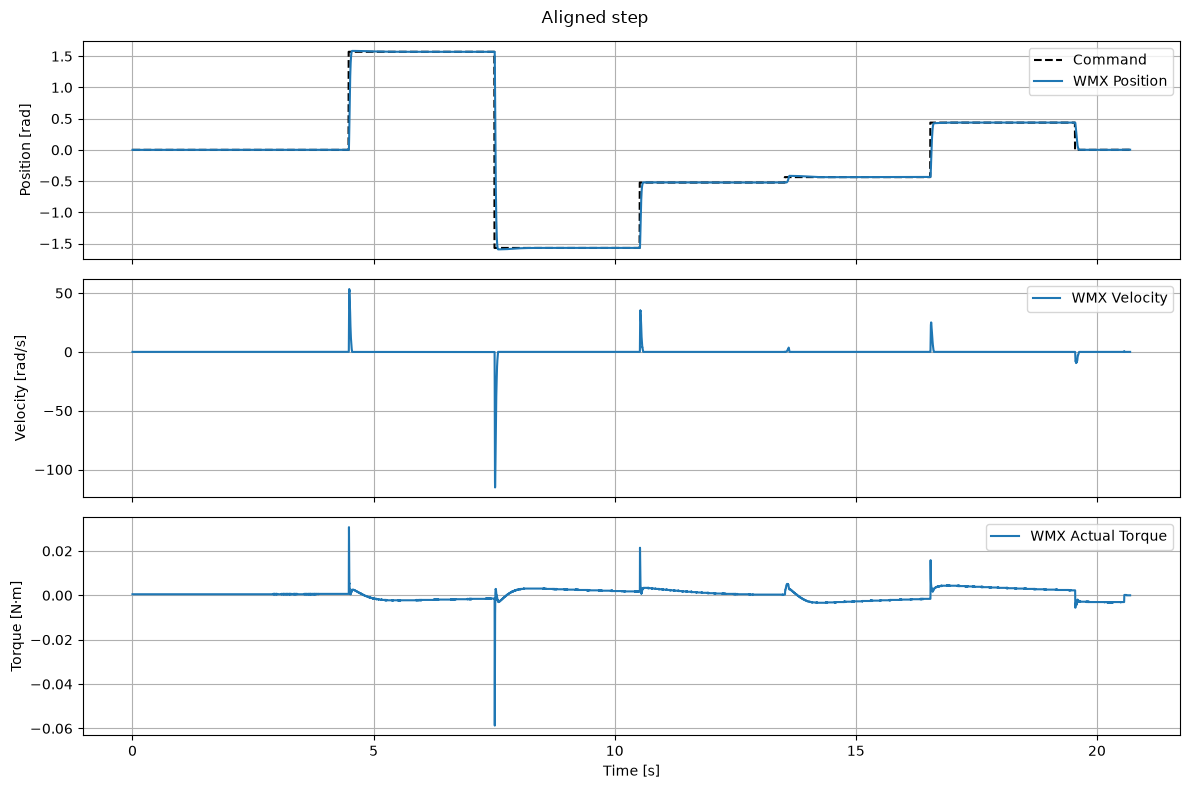

ramp               origin=-6.28397rad q0=-4.15703e-05rad v0=+9.39157e-15rad/s


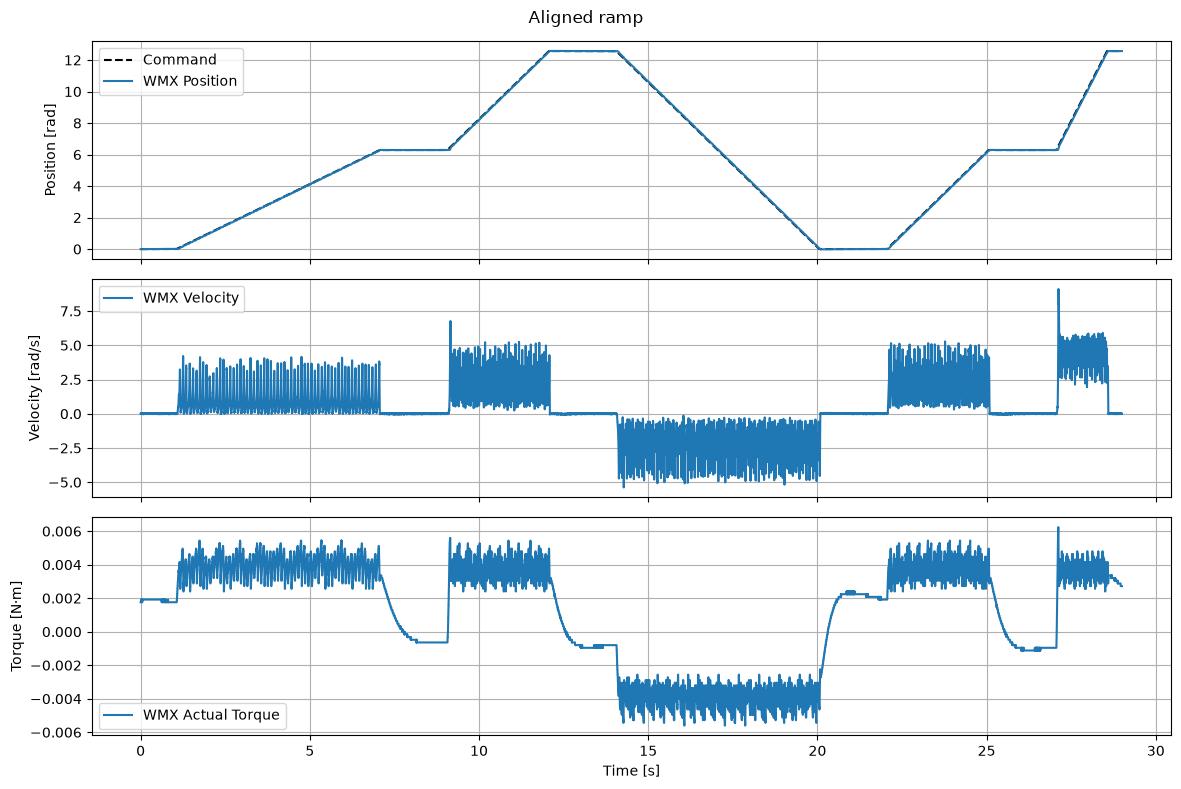

sine_0.1hz         origin=+0.000211971rad q0=-4.60786e-19rad v0=+1.34091e-15rad/s


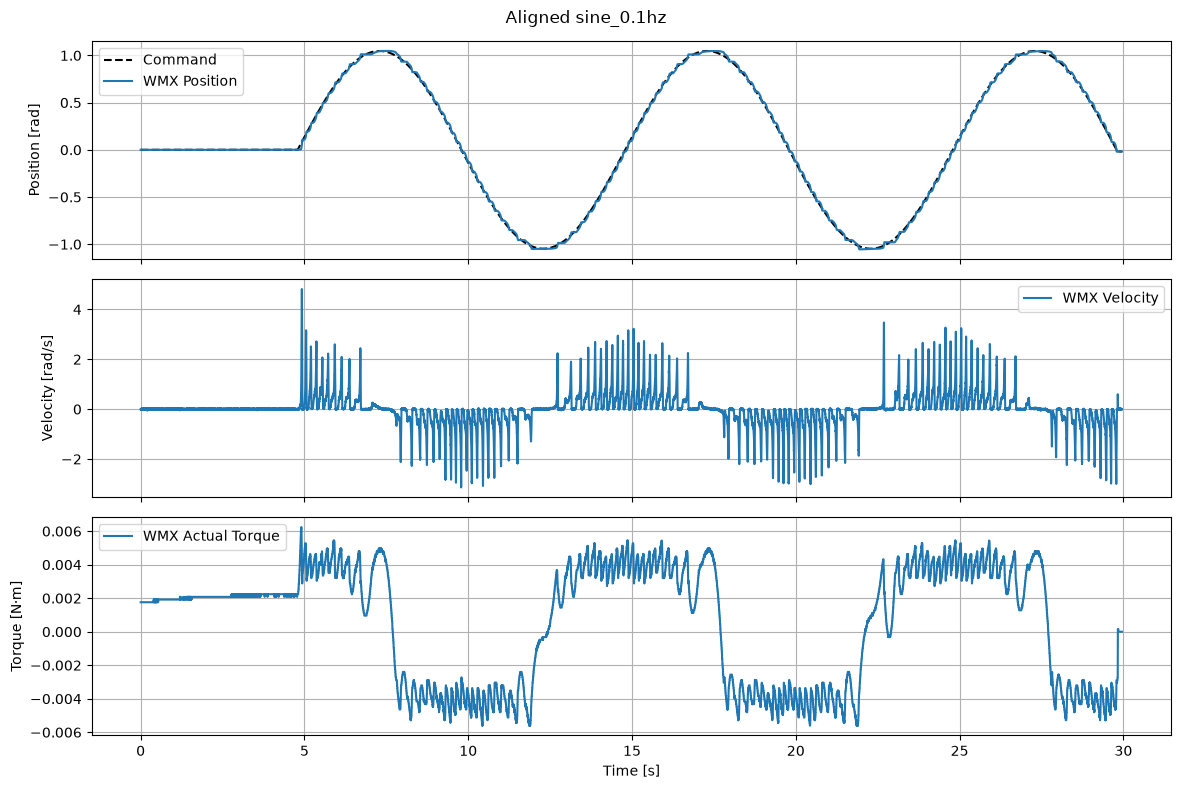

sine_0.2hz         origin=+4.26938e-05rad q0=-7.49026e-07rad v0=+0rad/s


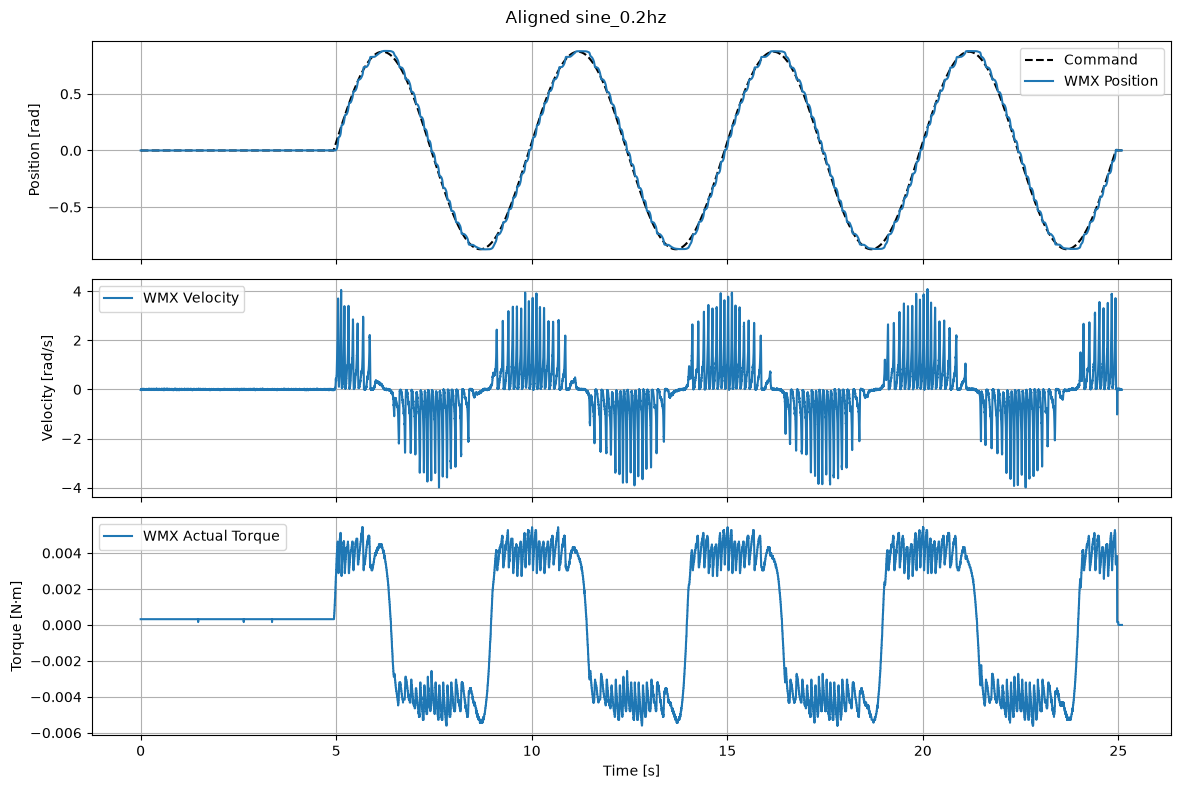

sine_0.5hz         origin=+1.40193rad q0=-0.0290853rad v0=+1.57593rad/s


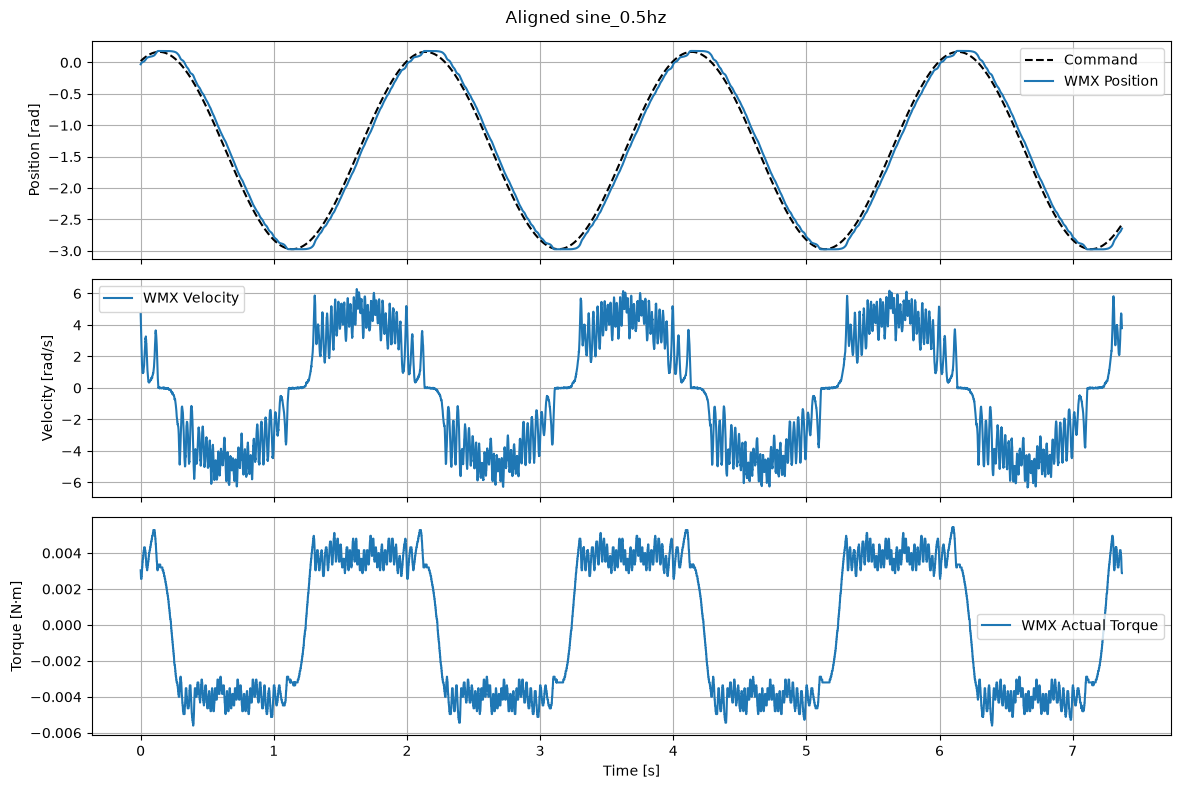

sine_1hz           origin=+0.45065rad q0=-0.0336895rad v0=+3.23574rad/s


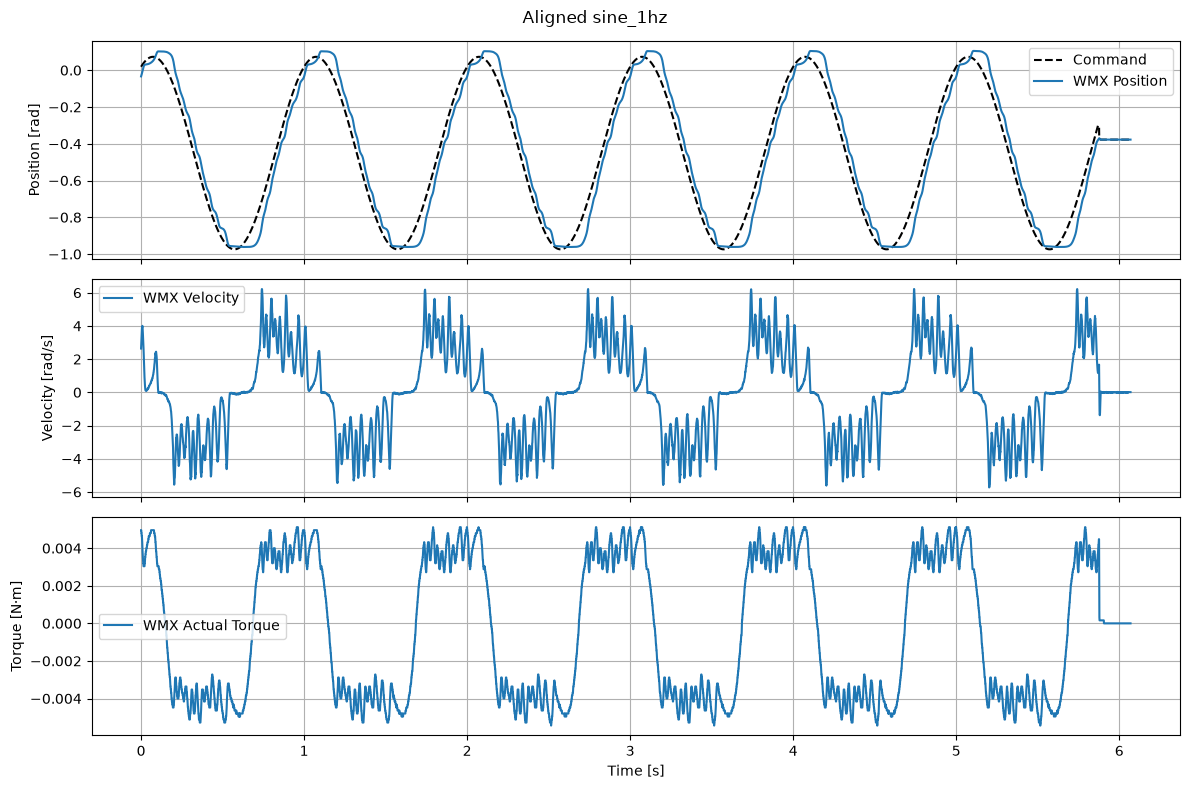

sine_2hz           origin=-0.2754rad q0=+0.00414355rad v0=-0.419448rad/s


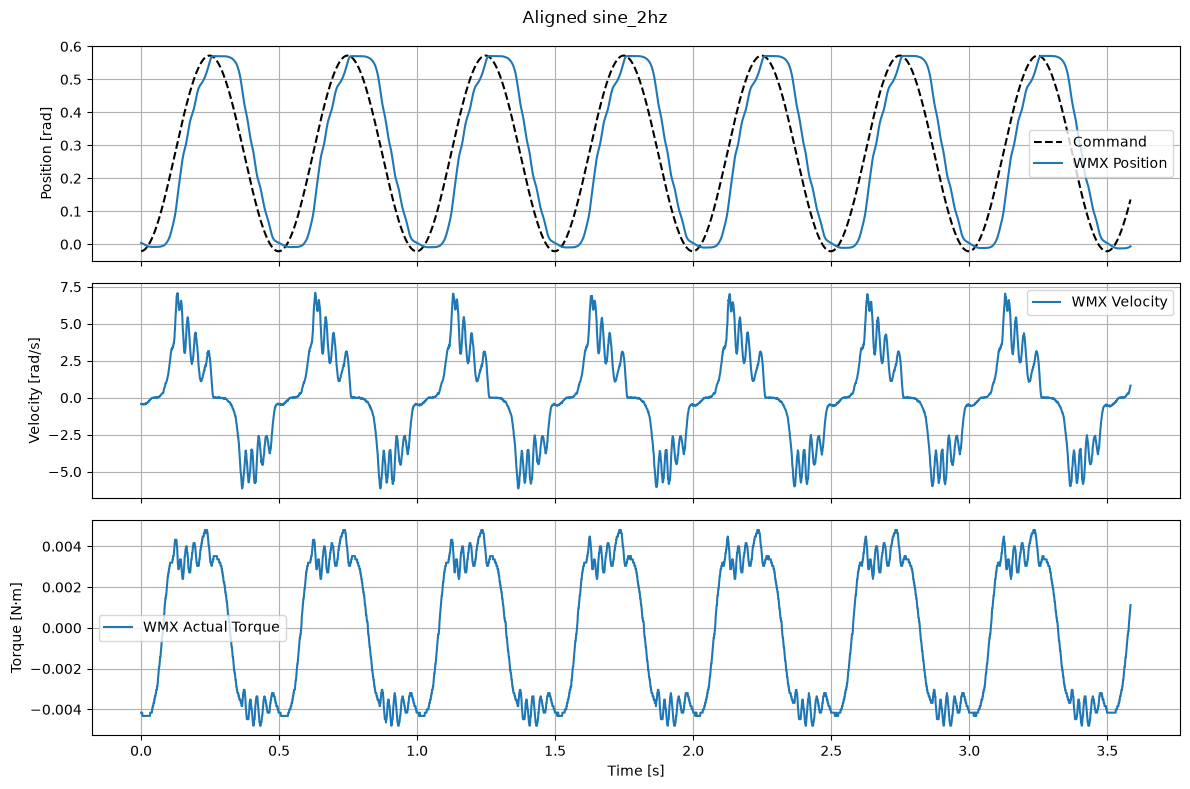

scurve_validation_1 origin=+1.49803e-06rad q0=-4.04468e-05rad v0=+1.98019e-15rad/s


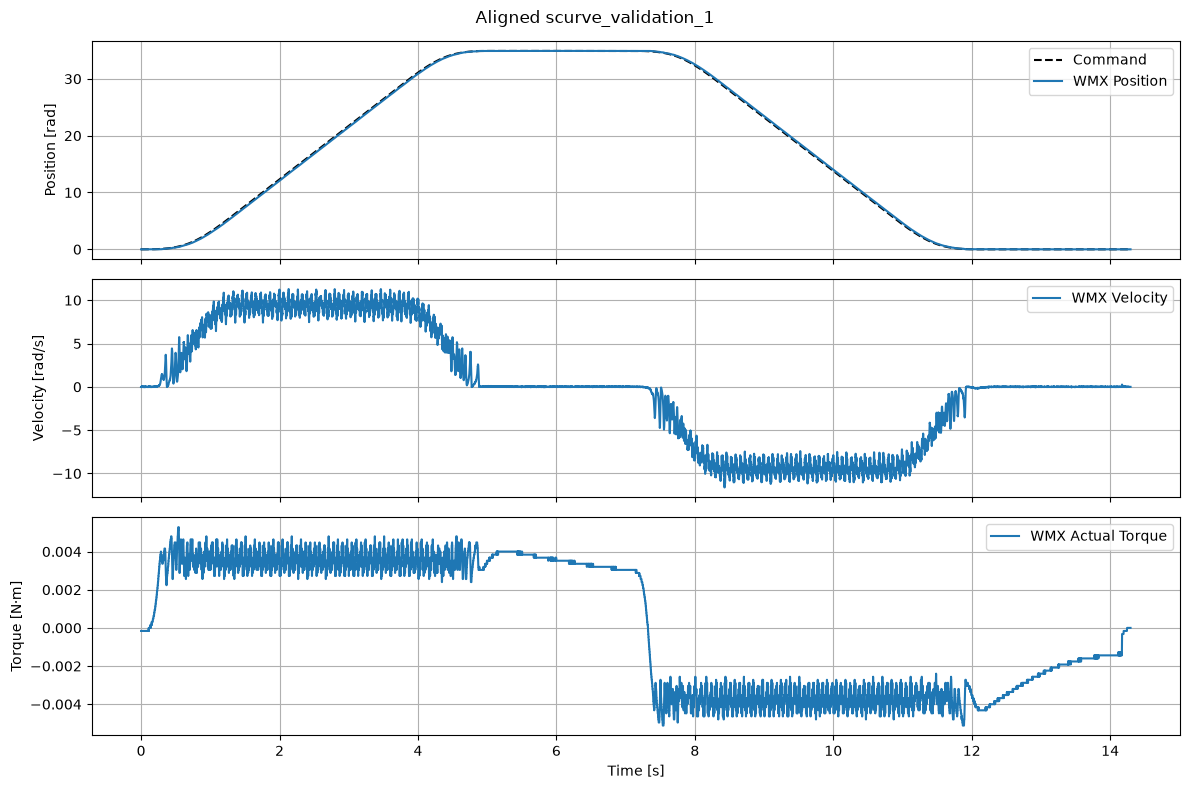

scurve_validation_2 origin=-0.000434803rad q0=+3.37057e-06rad v0=-1.58363e-14rad/s


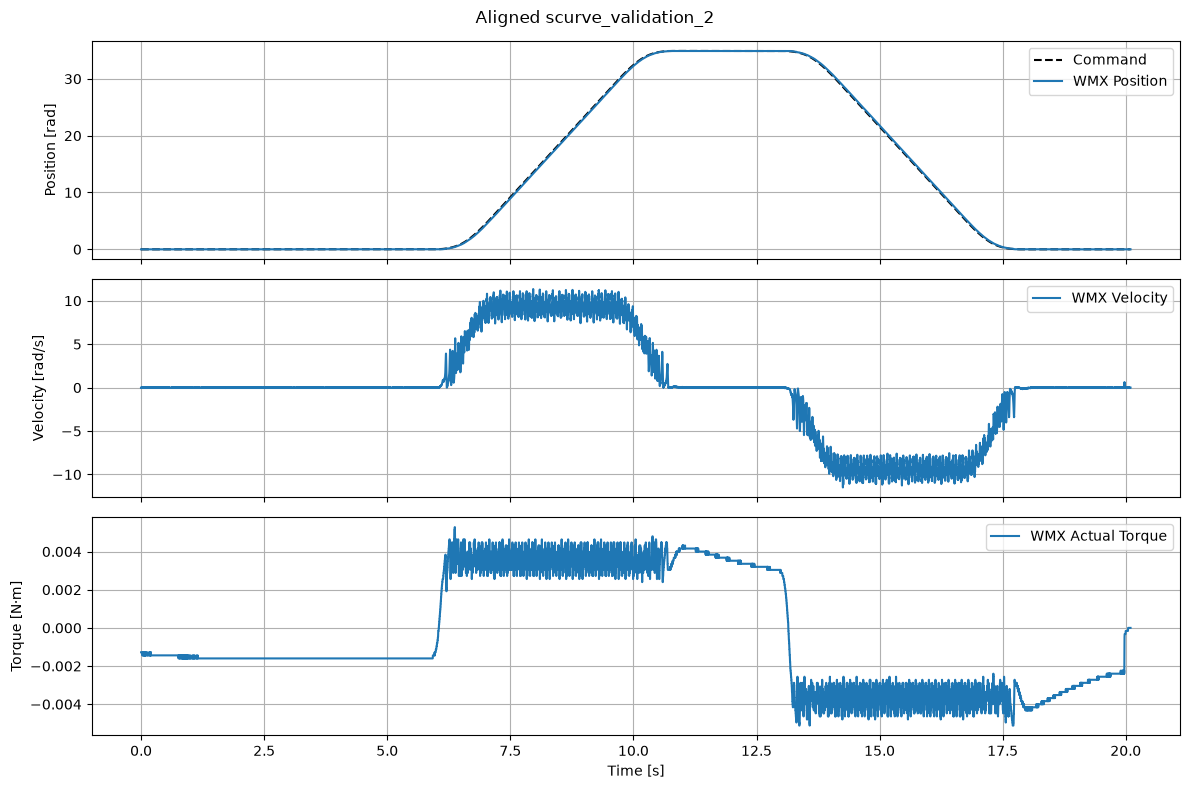

In [14]:
SIGNAL_KEYS = (
    "command_position", "feedback_position", "feedback_velocity", "feedback_torque",
)
INITIAL_WINDOW_S = 0.02


def align_log(data, profile):
    raw_time = np.asarray(data["time"], dtype=np.float64)
    dt = float(np.median(np.diff(raw_time)))
    count = int(np.floor((raw_time[-1] - raw_time[0]) / dt + 1.0e-9)) + 1
    time_axis = np.arange(count, dtype=np.float64) * dt
    result = {
        key: np.interp(time_axis, raw_time - raw_time[0], data[key])
        for key in SIGNAL_KEYS
    }
    initial_count = min(count, max(3, int(round(INITIAL_WINDOW_S / dt))))
    position_origin = float(np.median(result["feedback_position"][:initial_count]))
    initial_velocity = float(np.median(result["feedback_velocity"][:initial_count]))

    result["command_position"] -= position_origin
    result["feedback_position"] -= position_origin
    result.update({
        "profile": profile,
        "source": data["source"],
        "time": time_axis,
        "dt": dt,
        "source_dt": dt,
        "position_origin": position_origin,
        "initial_position": float(result["feedback_position"][0]),
        "initial_velocity": initial_velocity,
    })
    return result


datasets = {name: align_log(data, name) for name, data in raw_logs.items()}
fit_datasets = [datasets[name] for name in fit_dataset_names]
validation_datasets = [datasets[name] for name in validation_dataset_names]


def plot_log(data, title):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(data["time"], data["command_position"], "k--", label="Command")
    axes[0].plot(data["time"], data["feedback_position"], label="WMX Position")
    axes[1].plot(data["time"], data["feedback_velocity"], label="WMX Velocity")
    axes[2].plot(data["time"], data["feedback_torque"], label="WMX Actual Torque")
    for axis in axes:
        axis.grid(True); axis.legend()
    axes[0].set_ylabel("Position [rad]")
    axes[1].set_ylabel("Velocity [rad/s]")
    axes[2].set_ylabel("Torque [N·m]"); axes[2].set_xlabel("Time [s]")
    fig.suptitle(title); fig.tight_layout(); plt.show()


for name, data in datasets.items():
    print(
        f"{name:18s} origin={data['position_origin']:+.6g}rad "
        f"q0={data['initial_position']:+.6g}rad "
        f"v0={data['initial_velocity']:+.6g}rad/s"
    )
    plot_log(data, f"Aligned {name}")




## 3. Newton simulation과 Loss



In [15]:
SIGNALS = {
    "position": "feedback_position",
    "velocity": "feedback_velocity",
    "torque": "feedback_torque",
}
# 토크 오차는 임의의 0.5 N·m가 아니라 모터 정격토크로 정규화한다.
LOSS_SCALES = {"position": 0.05, "velocity": 0.5, "torque": RATED_TORQUE_NM}
DEFAULT_WEIGHTS = {"position": 1.0, "velocity": 0.7, "torque": 0.7}


def decimate_log(data, max_samples):
    stride = max(1, int(np.ceil(len(data["time"]) / max_samples)))
    if stride == 1:
        return data
    result = {key: np.asarray(data[key])[::stride] for key in SIGNAL_KEYS}
    result.update({
        "profile": data["profile"],
        "source": data["source"],
        "time": np.arange(len(result["command_position"])) * data["dt"] * stride,
        "dt": data["dt"] * stride,
        "source_dt": data["source_dt"],
        "position_origin": data["position_origin"],
        "initial_position": float(result["feedback_position"][0]),
        "initial_velocity": float(result["feedback_velocity"][0]),
    })
    return result


def slice_log(data, start, stop):
    result = {key: np.asarray(data[key])[start:stop] for key in SIGNAL_KEYS}
    result.update({
        "profile": data["profile"],
        "source": data["source"],
        "time": np.arange(stop - start) * data["dt"],
        "dt": data["dt"],
        "source_dt": data["source_dt"],
        "position_origin": data["position_origin"],
        "initial_position": float(result["feedback_position"][0]),
        "initial_velocity": float(result["feedback_velocity"][0]),
    })
    return result


def params_for_time_step(params, data):
    scaled_delay = int(round(params.delay_steps * data["source_dt"] / data["dt"]))
    return replace(params, delay_steps=max(0, scaled_delay))


def run_model(data, params, device=SIM_DEVICE):
    simulation_params = params_for_time_step(params, data)
    return simulate_motor(
        data["command_position"], data["dt"], simulation_params,
        device=device, use_viewer=False,
        initial_position=data["initial_position"],
        initial_velocity=data["initial_velocity"],
    )


def signal_losses(data, simulation, weights=DEFAULT_WEIGHTS):
    losses = {}
    for signal, key in SIGNALS.items():
        residual = (np.asarray(simulation[key]) - np.asarray(data[key])) / LOSS_SCALES[signal]
        losses[signal] = float(np.mean(residual ** 2))
    losses["total"] = sum(weights[key] * losses[key] for key in SIGNALS) / sum(weights.values())
    return losses


def healthy_simulation(data, simulation, params):
    finite = all(np.all(np.isfinite(simulation[key])) for key in SIGNALS.values())
    command_range = float(np.ptp(data["command_position"]))
    position_range = float(np.ptp(simulation["feedback_position"]))
    moving = command_range < 1.0e-3 or position_range >= max(1.0e-4, 0.01 * command_range)
    physical = (
        params.inertia > 0.0
        and params.peak_torque_limit >= params.continuous_torque_limit
        and params.peak_torque_limit > params.coulomb
    )
    return finite and moving and physical


def evaluate_params(items, params, weights=DEFAULT_WEIGHTS, progress_title=None, device=SIM_DEVICE):
    rows, simulations = [], []
    progress = ProgressBar(progress_title) if progress_title else None
    for index, data in enumerate(items, 1):
        simulation = run_model(data, params, device=device)
        rows.append(signal_losses(data, simulation, weights))
        simulations.append(simulation)
        if progress:
            progress.update(index, len(items), f"{index}/{len(items)} simulation", force=True)
    means = {
        key: float(np.mean([row[key] for row in rows]))
        for key in (*SIGNALS, "total")
    }
    return {"losses": means, "per_log": rows, "simulations": simulations}


def print_evaluation(label, params, evaluation, items):
    print(f"\n{label}\nparams = {asdict(params)}\nmean loss = {evaluation['losses']}")
    for data, loss in zip(items, evaluation["per_log"]):
        print(f"  {data['profile']:18s}: {loss}")


def plot_comparison(data, simulation, title):
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    axes[0].plot(data["time"], data["command_position"], "k--", label="Command")
    for axis, signal, ylabel in zip(
        axes,
        ("feedback_position", "feedback_velocity", "feedback_torque"),
        ("Position [rad]", "Velocity [rad/s]", "Torque [N·m]"),
    ):
        axis.plot(data["time"], data[signal], label="WMX")
        axis.plot(data["time"], simulation[signal], label="Newton")
        axis.set_ylabel(ylabel); axis.grid(True); axis.legend()
    axes[-1].set_xlabel("Time [s]")
    fig.suptitle(title); fig.tight_layout(); plt.show()


# 연속/피크 토크는 알려진 모터 사양으로 고정하고,
# PID·관성·마찰만 실제 로그에 맞는 규모에서 피팅한다.
current_params = MotorParams(
    kp=0.2, ki=0.0, kd=0.01,
    continuous_torque_limit=RATED_TORQUE_NM,
    peak_torque_limit=PEAK_TORQUE_NM,
    inertia=1.0e-3, viscous=1.0e-3, coulomb=0.0,
    delay_steps=1,
)
baseline = evaluate_params(
    [decimate_log(data, 1200) for data in fit_datasets],
    current_params,
    progress_title="Baseline Newton",
)
print_evaluation(
    "Baseline", current_params, baseline,
    [decimate_log(data, 1200) for data in fit_datasets],
)





Baseline
params = {'kp': 0.2, 'ki': 0.0, 'kd': 0.01, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 0.001, 'viscous': 0.001, 'coulomb': 0.0, 'delay_steps': 1, 'torque_response_time_constant': 0.0}
mean loss = {'position': 5.197202312965414, 'velocity': 17.878931929804338, 'torque': 0.020515023075050758, 'total': 7.386172991658744}
  step              : {'position': 9.90127553514916, 'velocity': 71.97846477697556, 'torque': 0.051413595717516525, 'total': 25.13424599834763}
  ramp              : {'position': 1.2522415150154125, 'velocity': 6.073194647336896, 'torque': 0.0009201228245562928, 'total': 2.293384105886845}
  sine_0.1hz        : {'position': 0.14425151761998814, 'velocity': 1.2597342126317788, 'torque': 0.0004136504077873428, 'total': 0.42764792572820187}
  sine_0.2hz        : {'position': 0.24121955638511142, 'velocity': 2.2230106262491294, 'torque': 0.00046892424265483986, 'total': 0.749023017387233

## 4. Step: delay 추정



각 Step onset delay: [7] → 중앙값: 7


선택한 delay_steps: 0


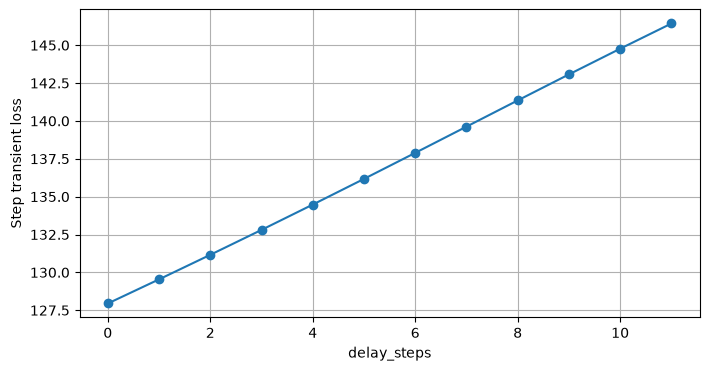

In [16]:
step_data = datasets["step"]
command_jump = np.abs(np.diff(step_data["command_position"], prepend=step_data["command_position"][0]))
jump_threshold = 0.25 * np.max(command_jump)
jump_indices = np.flatnonzero(command_jump >= jump_threshold)
jump_indices = jump_indices[np.r_[True, np.diff(jump_indices) > 10]]

onset_delays = []
for jump in jump_indices:
    before = step_data["feedback_torque"][max(0, jump - 100):jump]
    center = float(np.median(before))
    mad = float(np.median(np.abs(before - center))) + 1.0e-12
    threshold = max(8.0 * 1.4826 * mad, 0.05)
    after = np.abs(step_data["feedback_torque"][jump:jump + 50] - center)
    detected = np.flatnonzero(after > threshold)
    if len(detected):
        onset_delays.append(int(detected[0]))

if not onset_delays:
    raise RuntimeError("Step 토크 응답 onset을 찾지 못했습니다.")
onset_delay = int(round(np.median(onset_delays)))
delay_candidates = range(max(0, onset_delay - 7), onset_delay + 5)
print("각 Step onset delay:", onset_delays, "→ 중앙값:", onset_delay)

first_jump = int(jump_indices[0])
step_window = slice_log(
    step_data,
    max(0, first_jump - int(round(0.10 / step_data["dt"]))),
    min(len(step_data["time"]), first_jump + int(round(0.50 / step_data["dt"]))),
)
STEP_WEIGHTS = {"position": 0.4, "velocity": 0.8, "torque": 1.5}
delay_rows = []
progress = ProgressBar("Step delay sweep")
for index, delay in enumerate(delay_candidates, 1):
    candidate = replace(current_params, delay_steps=int(delay))
    evaluation = evaluate_params([step_window], candidate, STEP_WEIGHTS)
    delay_rows.append({"delay_steps": delay, **evaluation["losses"]})
    progress.update(index, len(delay_candidates), f"delay={delay}", force=True)

selected_delay = min(delay_rows, key=lambda row: row["total"])["delay_steps"]
current_params = replace(current_params, delay_steps=int(selected_delay))
print("선택한 delay_steps:", selected_delay)
plt.figure(figsize=(8, 4))
plt.plot([row["delay_steps"] for row in delay_rows], [row["total"] for row in delay_rows], "o-")
plt.xlabel("delay_steps"); plt.ylabel("Step transient loss"); plt.grid(True); plt.show()





## 5. Ramp: 마찰 초기값 추정



정상속도 samples: 4058
마찰 초기값: {'viscous': 2.925634236912447e-12, 'coulomb': 0.004161931981055078}


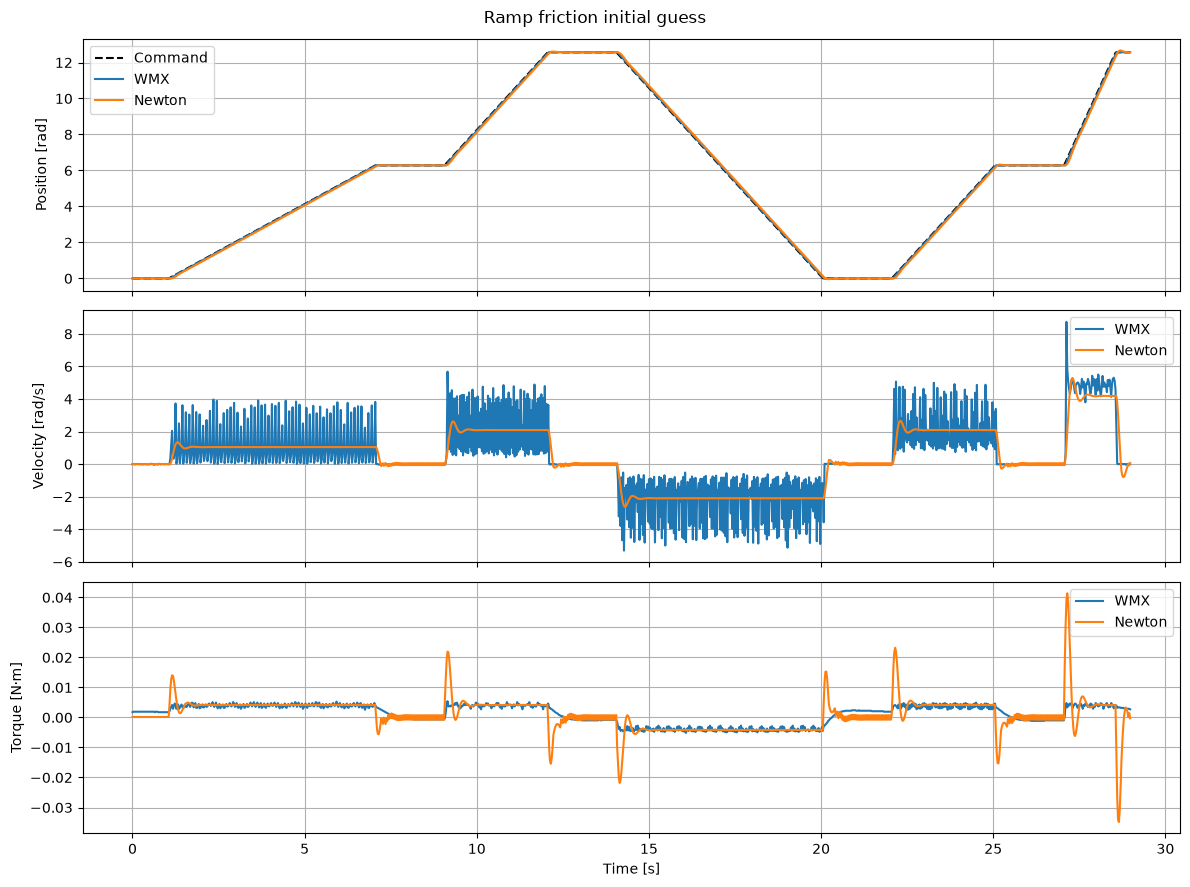

In [17]:
ramp_data = datasets["ramp"]
velocity = np.asarray(ramp_data["feedback_velocity"])
torque = np.asarray(ramp_data["feedback_torque"])
acceleration = np.gradient(velocity, ramp_data["dt"])
moving_threshold = max(0.02, 0.15 * np.quantile(np.abs(velocity), 0.95))
acceleration_limit = np.quantile(np.abs(acceleration), 0.60)
steady = (np.abs(velocity) >= moving_threshold) & (np.abs(acceleration) <= acceleration_limit)
X = np.column_stack((velocity[steady], np.sign(velocity[steady])))
y = torque[steady]

if len(y) < 20 or np.linalg.matrix_rank(X) < 2:
    raise RuntimeError("Ramp 로그에 양/음 방향 정상속도 구간이 충분하지 않습니다.")
friction_result = lsq_linear(X, y, bounds=(0.0, np.inf))
viscous0, coulomb0 = map(float, friction_result.x)
current_params = replace(current_params, viscous=viscous0, coulomb=coulomb0)
print("정상속도 samples:", int(np.sum(steady)))
print("마찰 초기값:", {"viscous": viscous0, "coulomb": coulomb0})

ramp_view = decimate_log(ramp_data, 1200)
ramp_initial = evaluate_params(
    [ramp_view], current_params,
    weights={"position": 0.3, "velocity": 0.8, "torque": 1.2},
    progress_title="Ramp 마찰 초기값 확인",
)
plot_comparison(ramp_view, ramp_initial["simulations"][0], "Ramp friction initial guess")




## 6. Multi-sine: 관성, 제어 게인 초기값 추정



/tmp/ipykernel_20030/452858423.py:112: UserWarning: 후보가 시작값보다 좋지 않아 시작값을 유지합니다.
  warnings.warn("후보가 시작값보다 좋지 않아 시작값을 유지합니다.")



Multi-sine 초기 피팅
params = {'kp': 0.2, 'ki': 0.0, 'kd': 0.01, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 0.001, 'viscous': 2.925634236912447e-12, 'coulomb': 0.004161931981055078, 'delay_steps': 0, 'torque_response_time_constant': 0.0}
mean loss = {'position': 5.272610341234085, 'velocity': 9.60357347979427, 'torque': 0.018088139644030967, 'total': 5.725783348005682}
  sine_0.1hz        : {'position': 0.4025942832738826, 'velocity': 1.2687987330855666, 'torque': 0.00010559387144602065, 'total': 0.6428678356470449}
  sine_0.2hz        : {'position': 0.5260918070040072, 'velocity': 2.2372341461804606, 'torque': 0.0001363774981935871, 'total': 1.0628491460320708}
  sine_0.5hz        : {'position': 5.536428858876662, 'velocity': 4.616577567779466, 'torque': 0.006222175529840447, 'total': 3.9064383584515503}
  sine_1hz          : {'position': 4.065764733482284, 'velocity': 7.9882471068426115, 'torque': 0.01234734

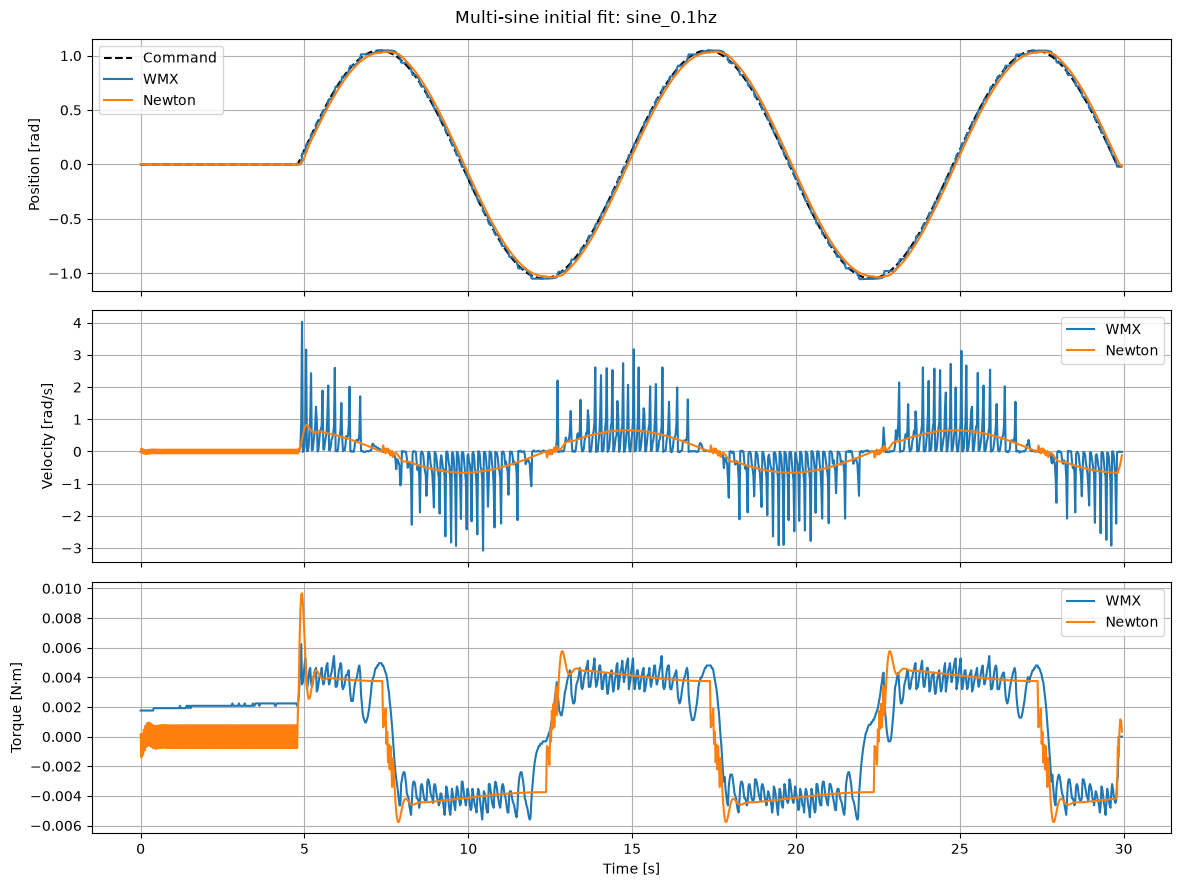

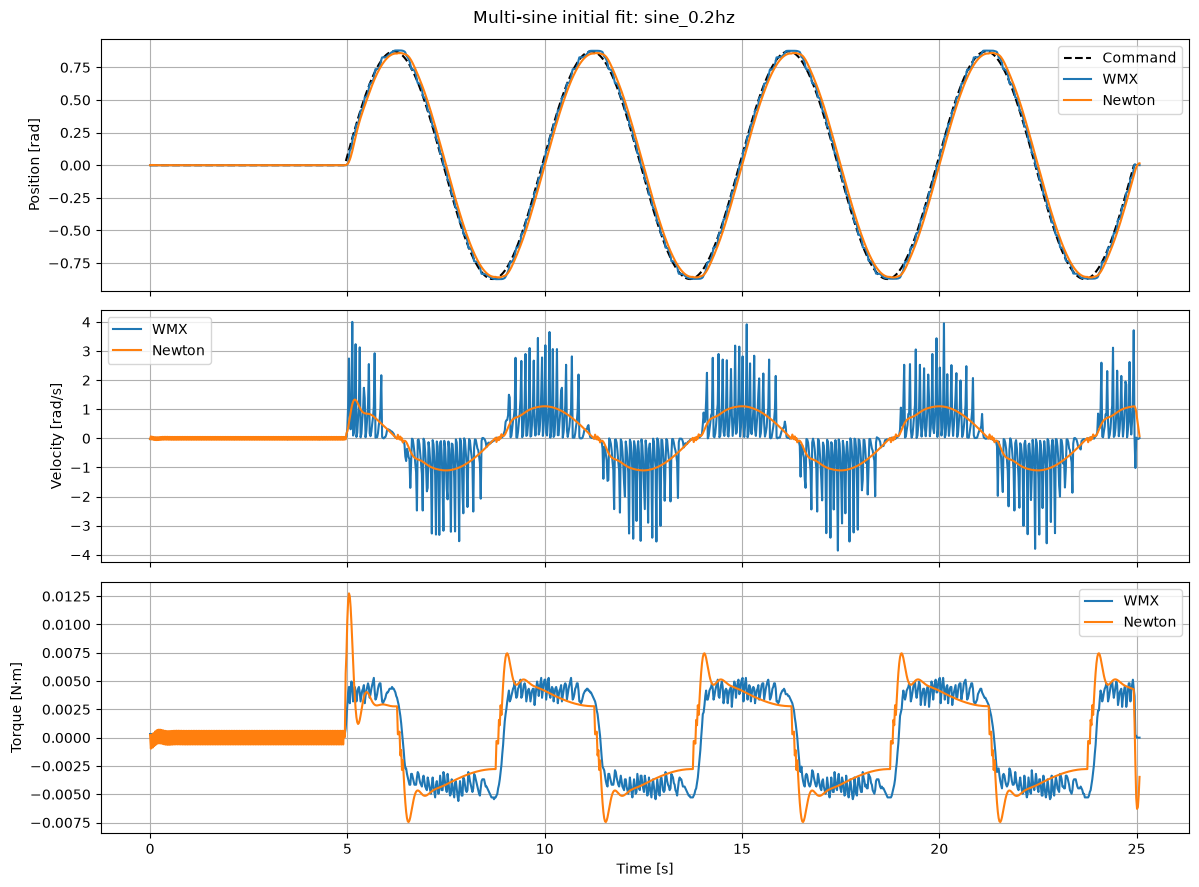

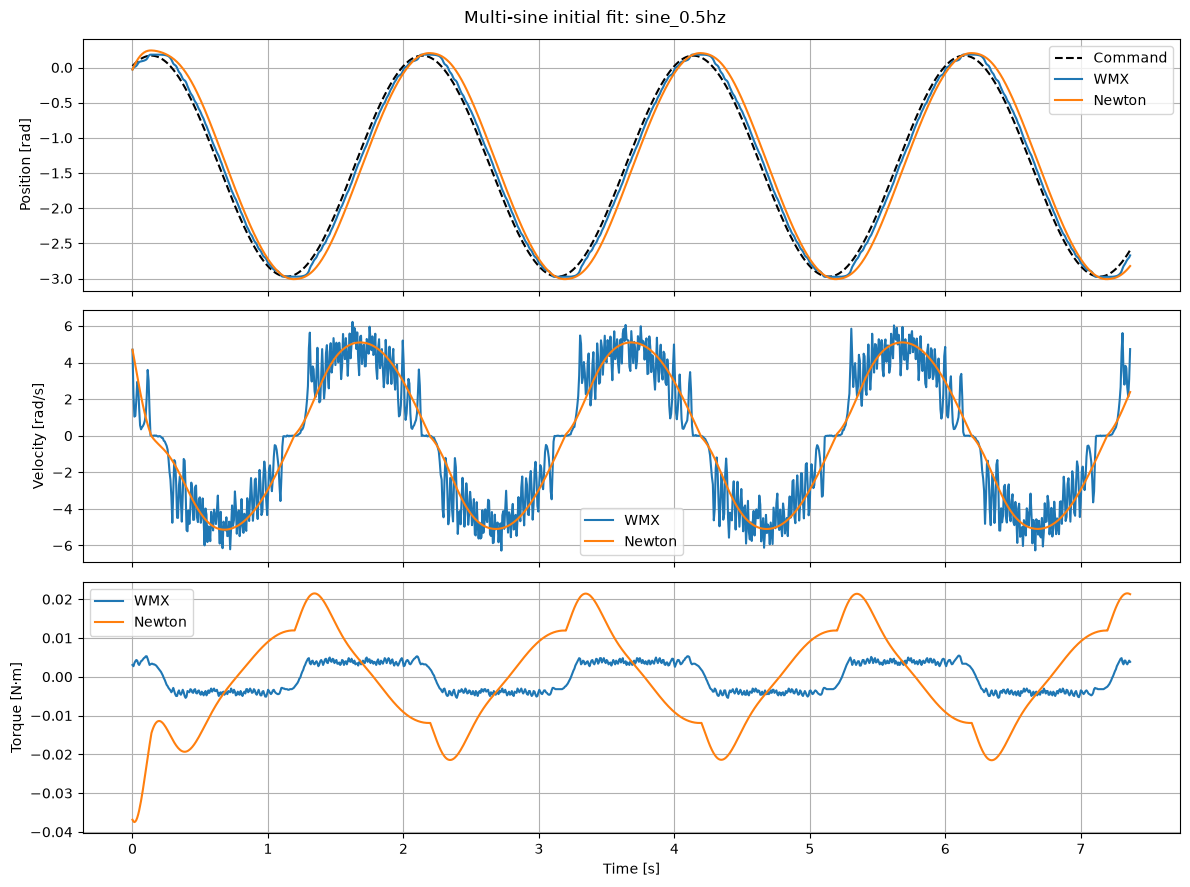

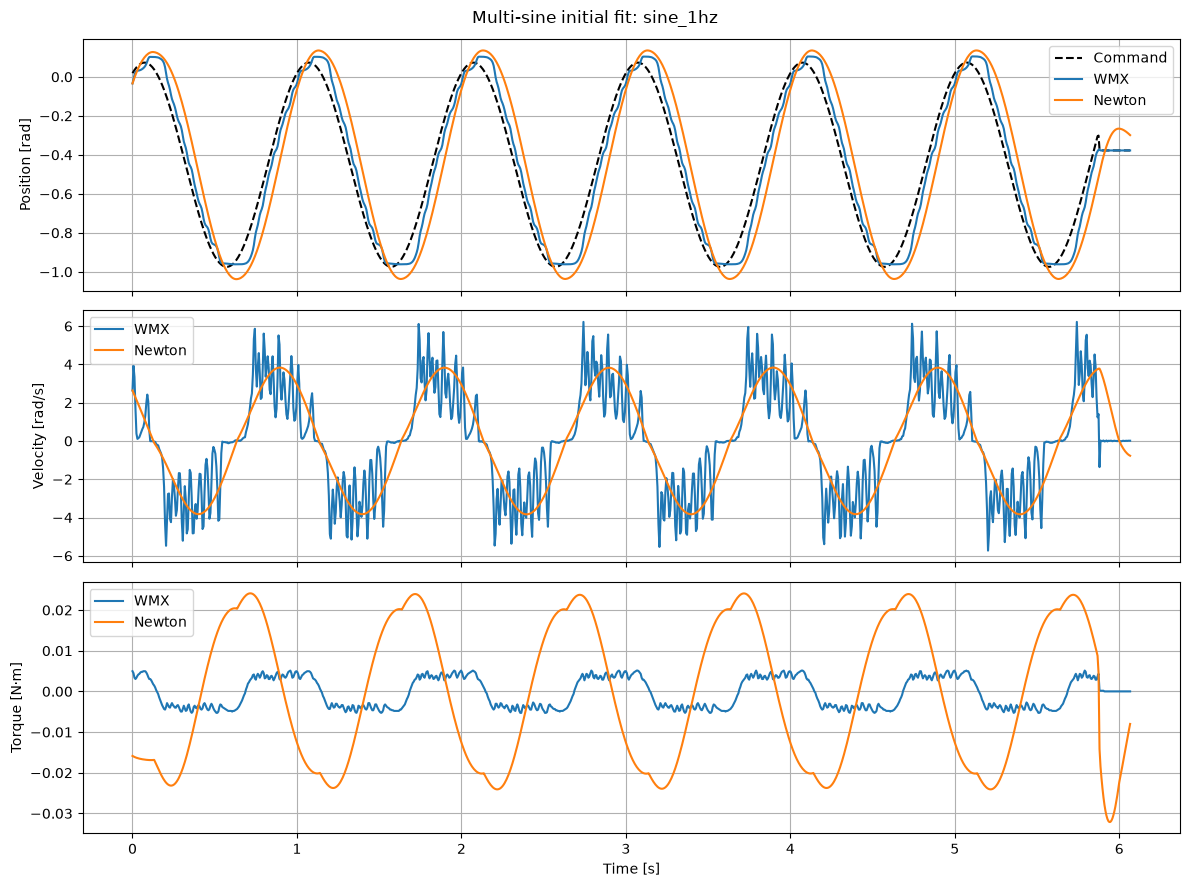

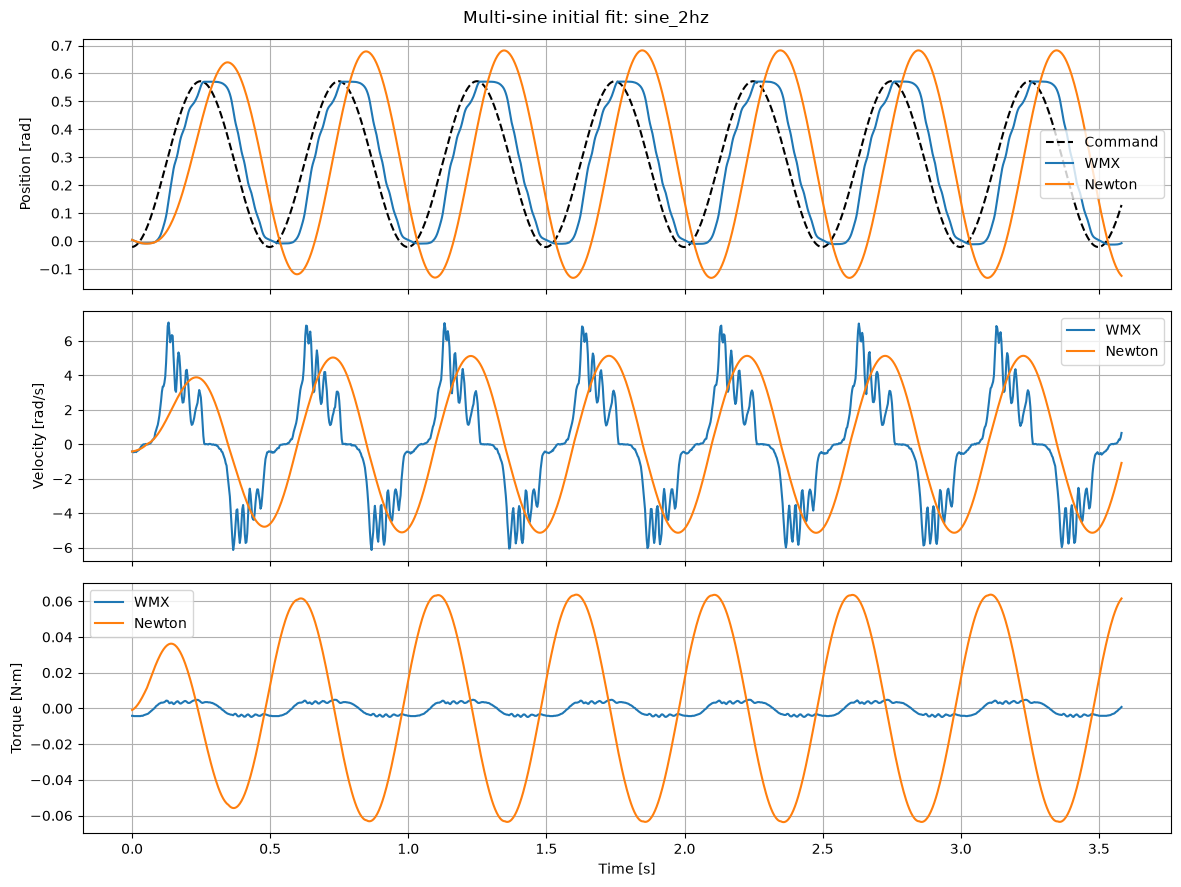

In [18]:
LOG_PARAMETERS = {"kp", "inertia"}


@dataclass
class FitResult:
    params: MotorParams
    before: dict
    after: dict
    evaluations: int


def decode_parameters(z, names, bounds, base_params):
    updates = {}
    for normalized, name in zip(z, names):
        lower, upper = bounds[name]
        if name in LOG_PARAMETERS and lower > 0.0:
            updates[name] = float(np.exp(np.log(lower) + normalized * np.log(upper / lower)))
        else:
            updates[name] = float(lower + normalized * (upper - lower))
    return replace(base_params, **updates)


# delay는 step sweep으로 따로 고정하고, 연속 파라미터만 현재 값 주변에서 미세조정한다.
REFINEMENT_LIMITS = {
    "kp": {"hard": (0.05, 3.0), "scale": (0.5, 1.5), "min_width": 0.10},
    "kd": {"hard": (5.0e-4, 0.15), "scale": (0.5, 1.5), "min_width": 2.0e-3},
    "inertia": {"hard": (ROTOR_INERTIA_KG_M2, 5.0e-4), "scale": (0.5, 1.5), "min_width": 2.5e-5},
    "viscous": {"hard": (1.0e-5, 5.0e-3), "scale": (0.5, 2.0), "min_width": 2.0e-4},
    "coulomb": {"hard": (0.0, 5.0e-2), "scale": (0.5, 1.5), "min_width": 1.0e-3},
}


def bounds_around(params):
    bounds = {}
    for name, spec in REFINEMENT_LIMITS.items():
        value = float(getattr(params, name))
        hard_min, hard_max = map(float, spec["hard"])
        if name == "coulomb":
            hard_max = min(hard_max, float(params.peak_torque_limit) * 0.95)
        lower_scale, upper_scale = spec["scale"]
        lower = value * lower_scale
        upper = value * upper_scale
        width = max(upper - lower, float(spec["min_width"]))
        if value <= hard_min:
            lower = hard_min
            upper = hard_min + width
        else:
            lower = value - 0.5 * width
            upper = value + 0.5 * width
        lower = float(max(hard_min, lower))
        upper = float(min(hard_max, upper))
        if upper <= lower:
            lower = hard_min
            upper = hard_max
        bounds[name] = (lower, upper)
    return bounds


def make_objective(items, base_params, bounds, weights, progress, total_evaluations):
    names = tuple(bounds)
    counter = {"value": 0}

    def objective(z):
        counter["value"] += 1
        try:
            params = decode_parameters(z, names, bounds, base_params)
            if params.peak_torque_limit <= params.coulomb:
                loss = 1.0e12
            else:
                evaluation = evaluate_params(items, params, weights)
                healthy = all(
                    healthy_simulation(data, simulation, params)
                    for data, simulation in zip(items, evaluation["simulations"])
                )
                loss = evaluation["losses"]["total"] if healthy else 1.0e12
        except (FloatingPointError, OverflowError, ValueError, RuntimeError):
            loss = 1.0e12
        displayed = min(counter["value"], max(total_evaluations - 1, 0))
        progress.update(
            displayed, total_evaluations,
            f"평가 {counter['value']} · 예상 예산 {total_evaluations} · loss={loss:.6g}",
        )
        return loss

    return objective, counter


def fit_global_local(items, base_params, bounds, weights, title,
                     de_maxiter=6, de_popsize=4, local_maxfun=60, seed=42):
    names = tuple(bounds)
    unit_bounds = [(0.0, 1.0)] * len(names)
    before = evaluate_params(items, base_params, weights)
    global_budget = (de_maxiter + 1) * de_popsize * len(names)
    total_budget = global_budget + local_maxfun
    progress = ProgressBar(title)
    objective, counter = make_objective(
        items, base_params, bounds, weights, progress, total_budget,
    )
    global_result = differential_evolution(
        objective, unit_bounds, seed=seed, maxiter=de_maxiter, popsize=de_popsize,
        polish=False, workers=1, updating="immediate",
    )
    local_result = minimize(
        objective, global_result.x, method="L-BFGS-B", bounds=unit_bounds,
        options={"maxiter": local_maxfun, "maxfun": local_maxfun, "eps": 2.0e-3},
    )
    best_z = local_result.x if local_result.fun < global_result.fun else global_result.x
    candidate = decode_parameters(best_z, names, bounds, base_params)
    progress.update(total_budget - 1, total_budget, "최적 후보 재검증", force=True)
    after = evaluate_params(items, candidate, weights)
    if after["losses"]["total"] >= before["losses"]["total"]:
        warnings.warn("후보가 시작값보다 좋지 않아 시작값을 유지합니다.")
        candidate, after = base_params, before
    progress.update(total_budget, total_budget, f"완료 · loss={after['losses']['total']:.6g}", force=True)
    return FitResult(candidate, before, after, counter["value"])


def sweep_delay_steps(items, base_params, delay_candidates, weights, title):
    delay_rows = []
    progress = ProgressBar(title)
    best_delay = int(base_params.delay_steps)
    best_evaluation = None
    for index, delay in enumerate(delay_candidates, 1):
        candidate = replace(base_params, delay_steps=int(delay))
        evaluation = evaluate_params(items, candidate, weights)
        row = {"delay_steps": int(delay), **evaluation["losses"]}
        delay_rows.append(row)
        if best_evaluation is None or row["total"] < best_evaluation["losses"]["total"]:
            best_delay = int(delay)
            best_evaluation = evaluation
        progress.update(
            index, len(delay_candidates),
            f"delay={delay} · loss={row['total']:.6g}",
            force=True,
        )
    selected_params = replace(base_params, delay_steps=int(best_delay))
    return selected_params, delay_rows, best_evaluation


def encode_parameters(params, names, bounds):
    values = asdict(params)
    encoded = []
    for name in names:
        lower, upper = bounds[name]
        value = float(np.clip(values[name], lower, upper))
        if name in LOG_PARAMETERS and lower > 0.0:
            encoded.append(np.log(value / lower) / np.log(upper / lower))
        else:
            encoded.append((value - lower) / (upper - lower))
    return np.asarray(encoded, dtype=np.float64)


def fit_local_refinement(items, base_params, bounds, weights, title,
                         budget=140, maxiter=35):
    names = tuple(bounds)
    progress = ProgressBar(title)
    objective, counter = make_objective(
        items, base_params, bounds, weights, progress, budget,
    )
    z0 = encode_parameters(base_params, names, bounds)
    result = minimize(
        objective, z0, method="L-BFGS-B",
        bounds=[(0.0, 1.0)] * len(names),
        options={"maxiter": maxiter, "maxfun": budget, "eps": 2.0e-3},
    )
    candidate = decode_parameters(
        result.x, names, bounds, base_params,
    )
    progress.update(budget - 1, budget, "최적 후보 재검증", force=True)
    before = evaluate_params(items, base_params, weights)
    after = evaluate_params(items, candidate, weights)
    if after["losses"]["total"] >= before["losses"]["total"]:
        warnings.warn("전체 미세조정 결과가 개선되지 않아 현재 값을 유지합니다.")
        candidate, after = base_params, before
    progress.update(budget, budget, f"완료 · loss={after['losses']['total']:.6g}", force=True)
    return FitResult(candidate, before, after, counter["value"])


multi_sine_views = [decimate_log(datasets[name], 1200) for name in sine_dataset_names]
MULTI_SINE_BOUNDS = {
    "inertia": (ROTOR_INERTIA_KG_M2, 5.0e-4),
    "kp": (0.05, 3.0),
    "kd": (5.0e-4, 0.15),
}
MULTI_SINE_WEIGHTS = {"position": 1.0, "velocity": 1.0, "torque": 0.6}
multi_sine_fit = fit_global_local(
    multi_sine_views, current_params, MULTI_SINE_BOUNDS, MULTI_SINE_WEIGHTS,
    "Multi-sine inertia/kp/kd 초기값",
)
current_params = multi_sine_fit.params
print_evaluation(
    "Multi-sine 초기 피팅", current_params, multi_sine_fit.after, multi_sine_views,
)
for data, simulation in zip(multi_sine_views, multi_sine_fit.after["simulations"]):
    plot_comparison(data, simulation, f"Multi-sine initial fit: {data['profile']}")




## 7. Step + Ramp + Multi-sine 전체 Newton 응답 미세조정



delay 재확인: {'before': 0, 'after': 0, 'step_loss': 51.89750818753688, 'changed': False}



최종 fitting
params = {'kp': 0.23303367686865178, 'ki': 0.0, 'kd': 0.007724395727034785, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 0.0002240549907040991, 'viscous': 1.0000091888312144e-05, 'coulomb': 0.003432729715064069, 'delay_steps': 0, 'torque_response_time_constant': 0.0}
mean loss = {'position': 0.5509056064806864, 'velocity': 8.008794621472216, 'torque': 0.003474040429011382, 'total': 2.6772002061544877}
  step              : {'position': 1.679936124697237, 'velocity': 35.096085557876975, 'torque': 0.019119589298101123, 'total': 11.450807785552808}
  ramp              : {'position': 0.33334749278639025, 'velocity': 3.926854009208971, 'torque': 0.00013060037772356638, 'total': 1.3365135309445175}
  sine_0.1hz        : {'position': 0.1856128511194123, 'velocity': 1.096537668406747, 'torque': 8.856324301079076e-05, 'total': 0.408813014015084}
  sine_0.2hz        : {'position': 0.18818485881095234, 'velo

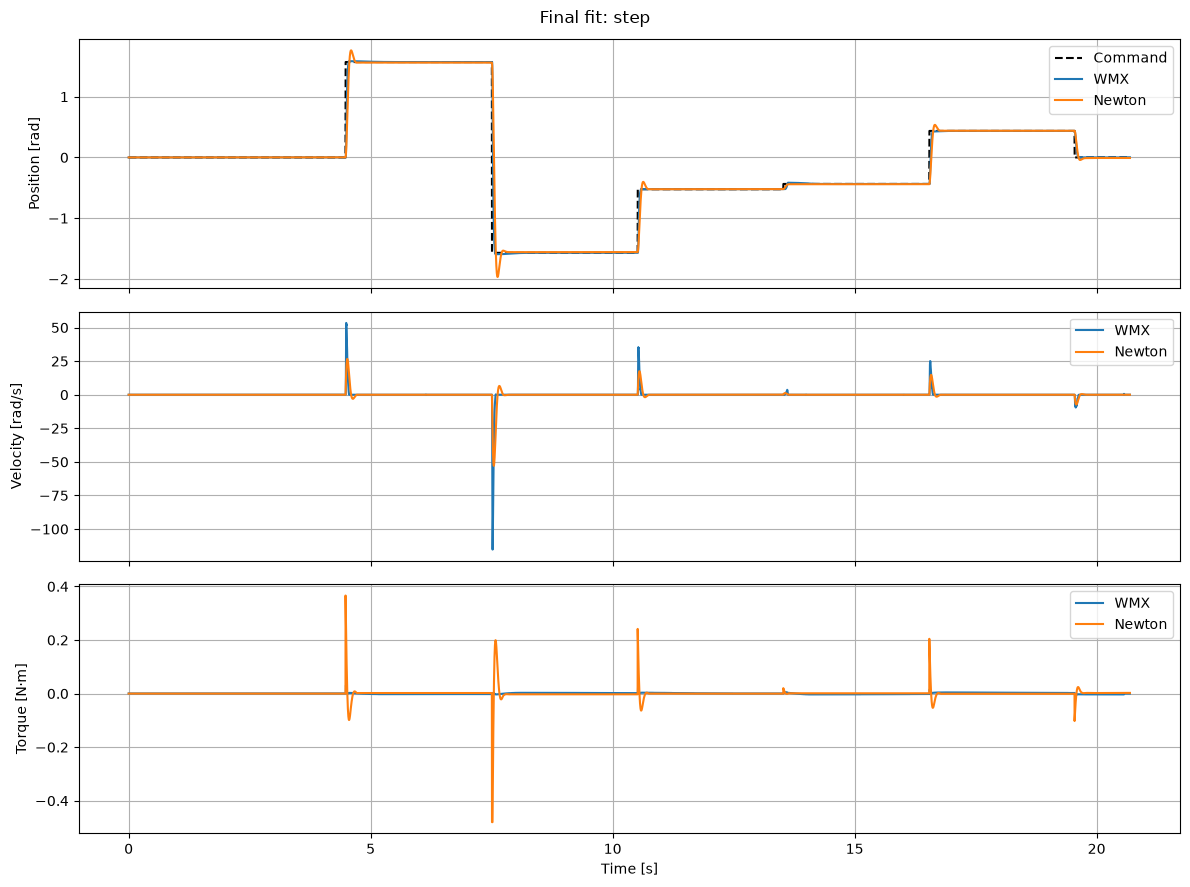

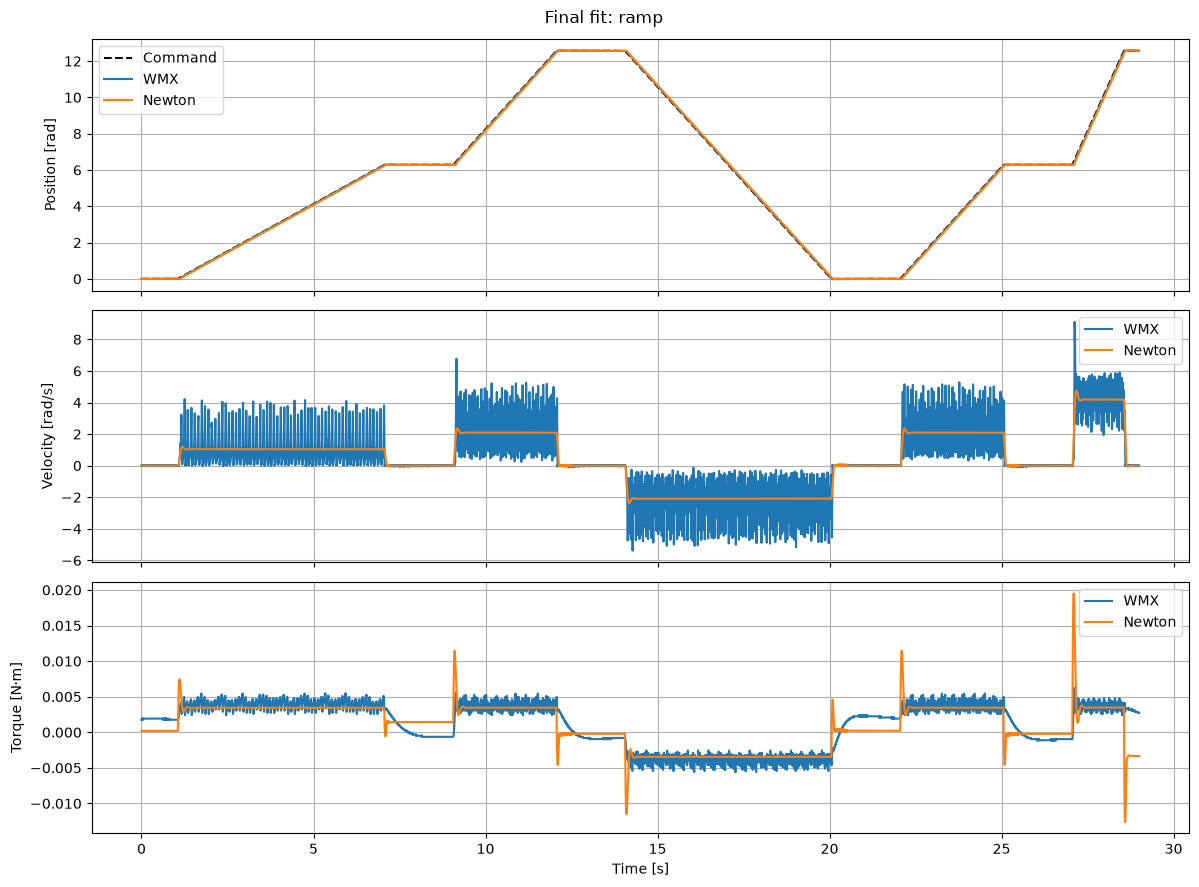

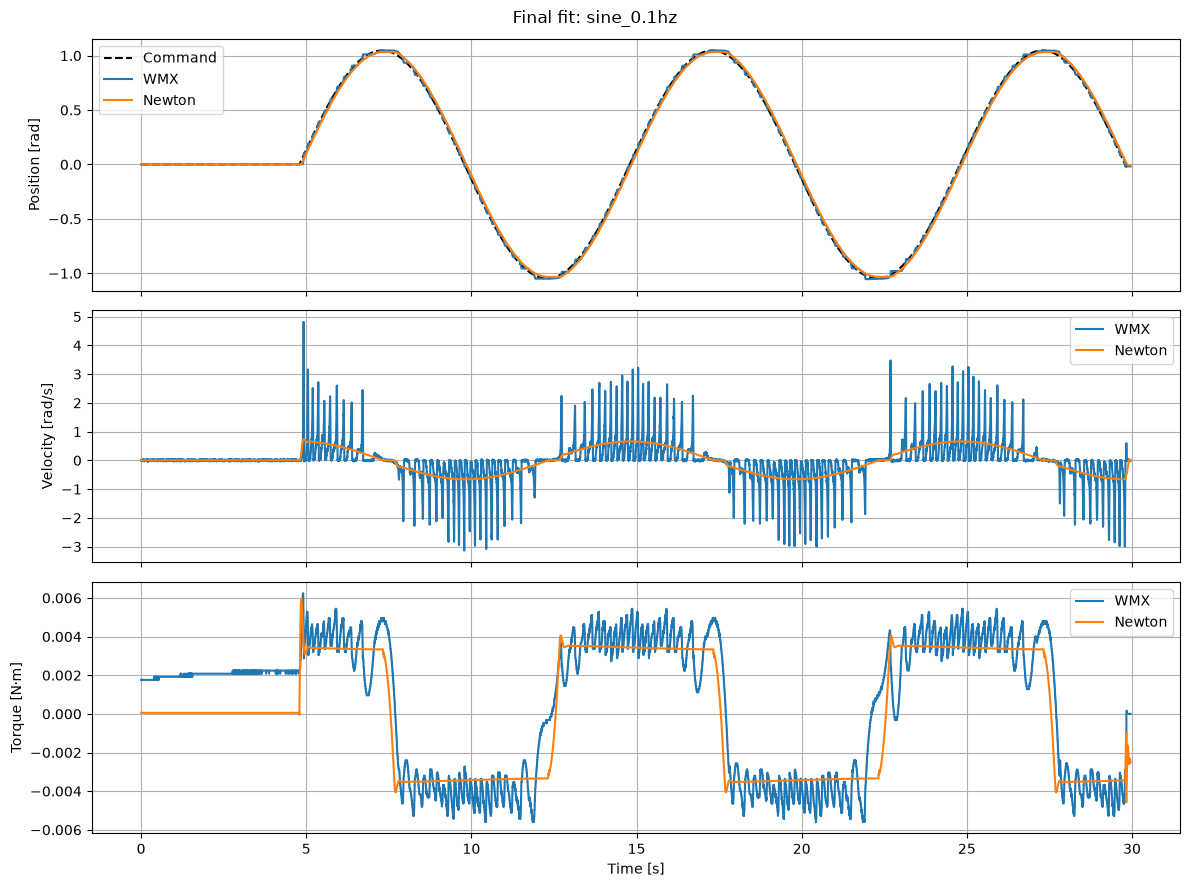

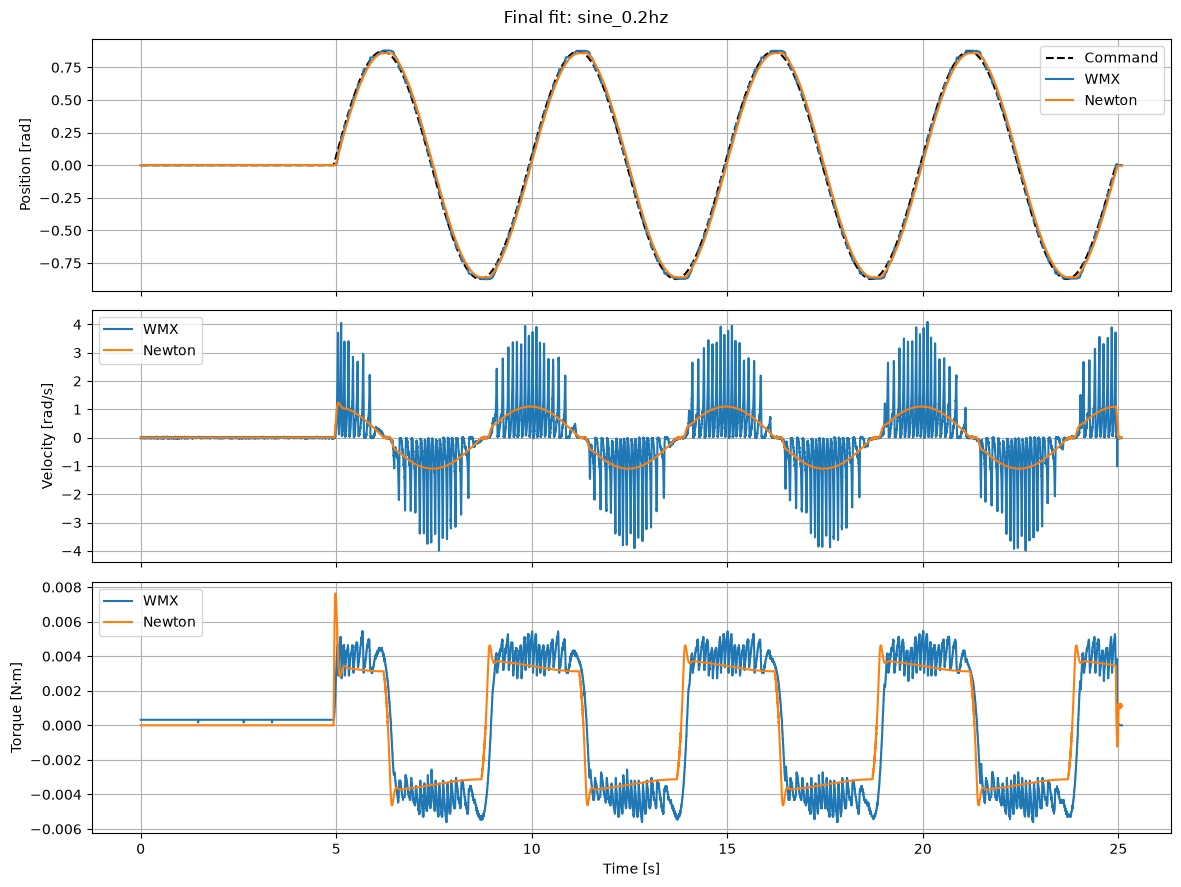

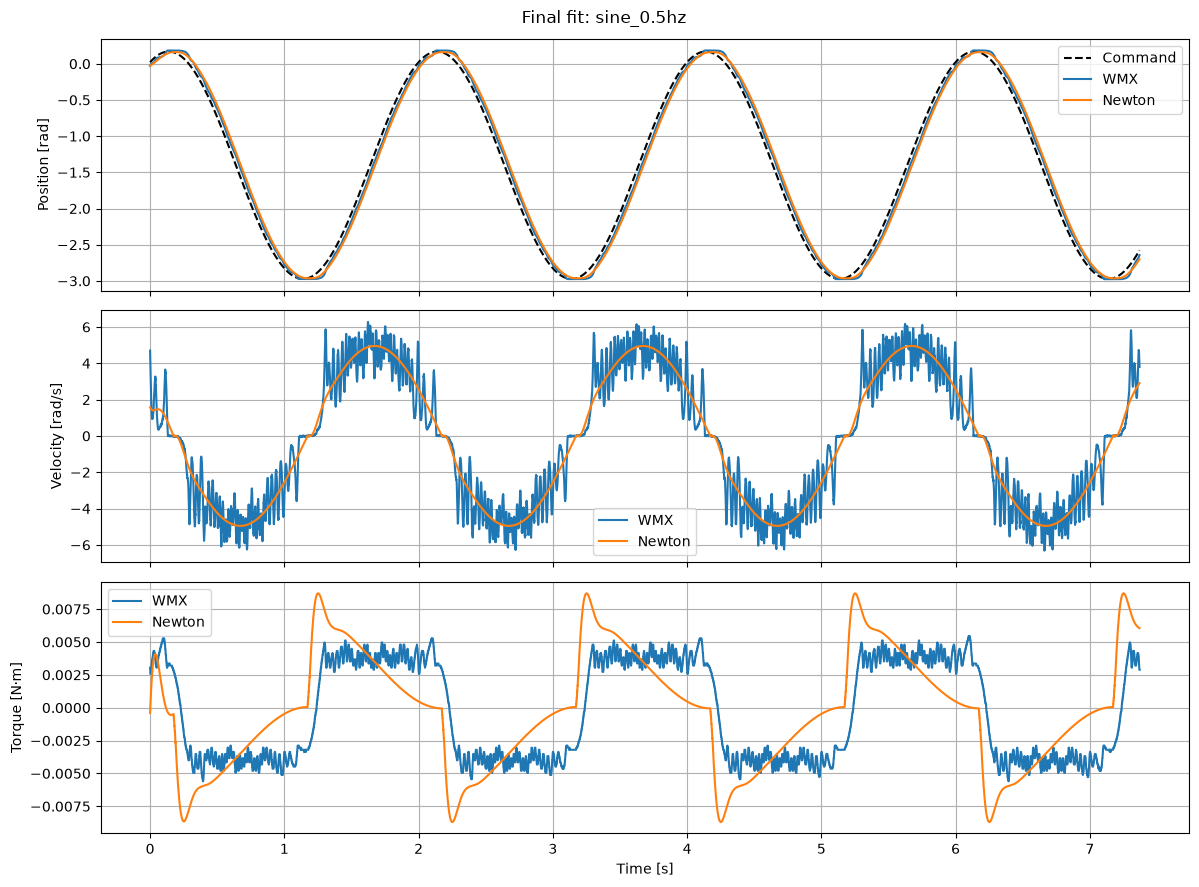

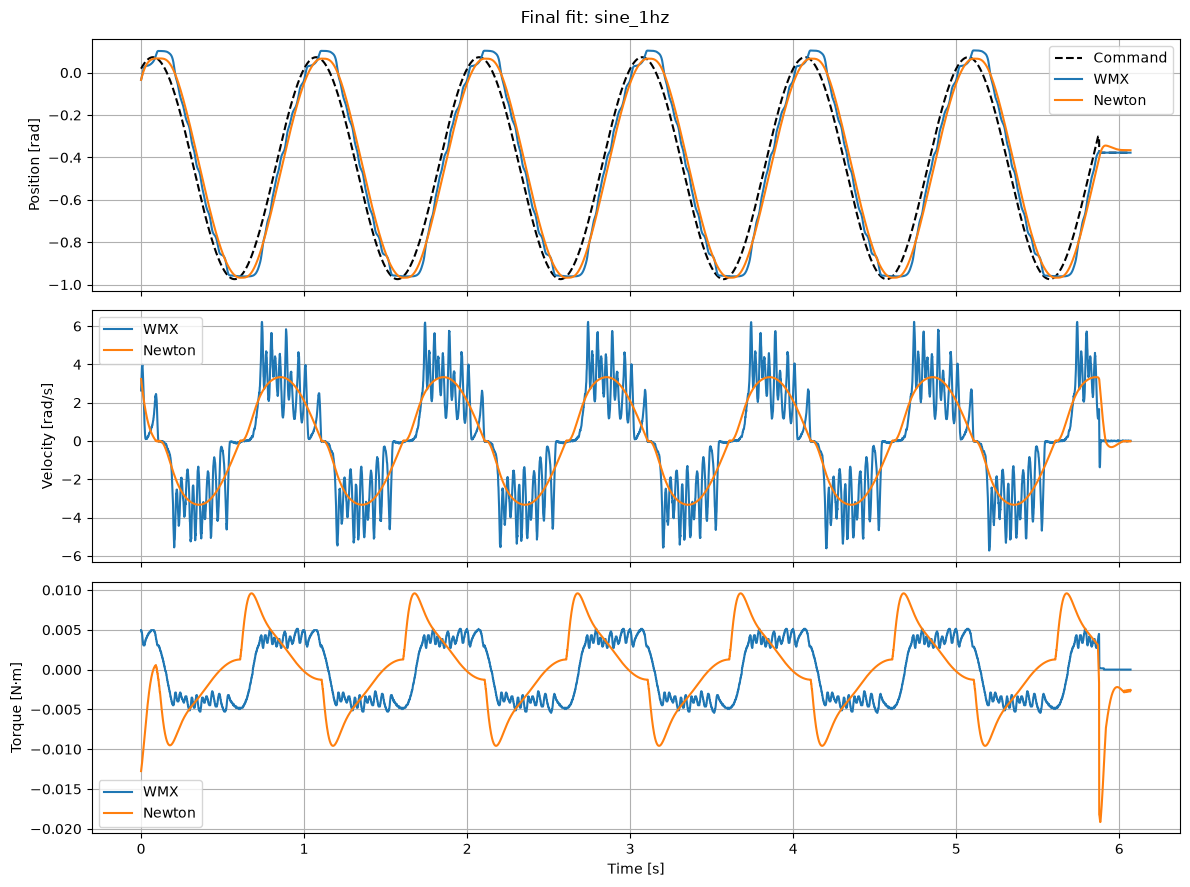

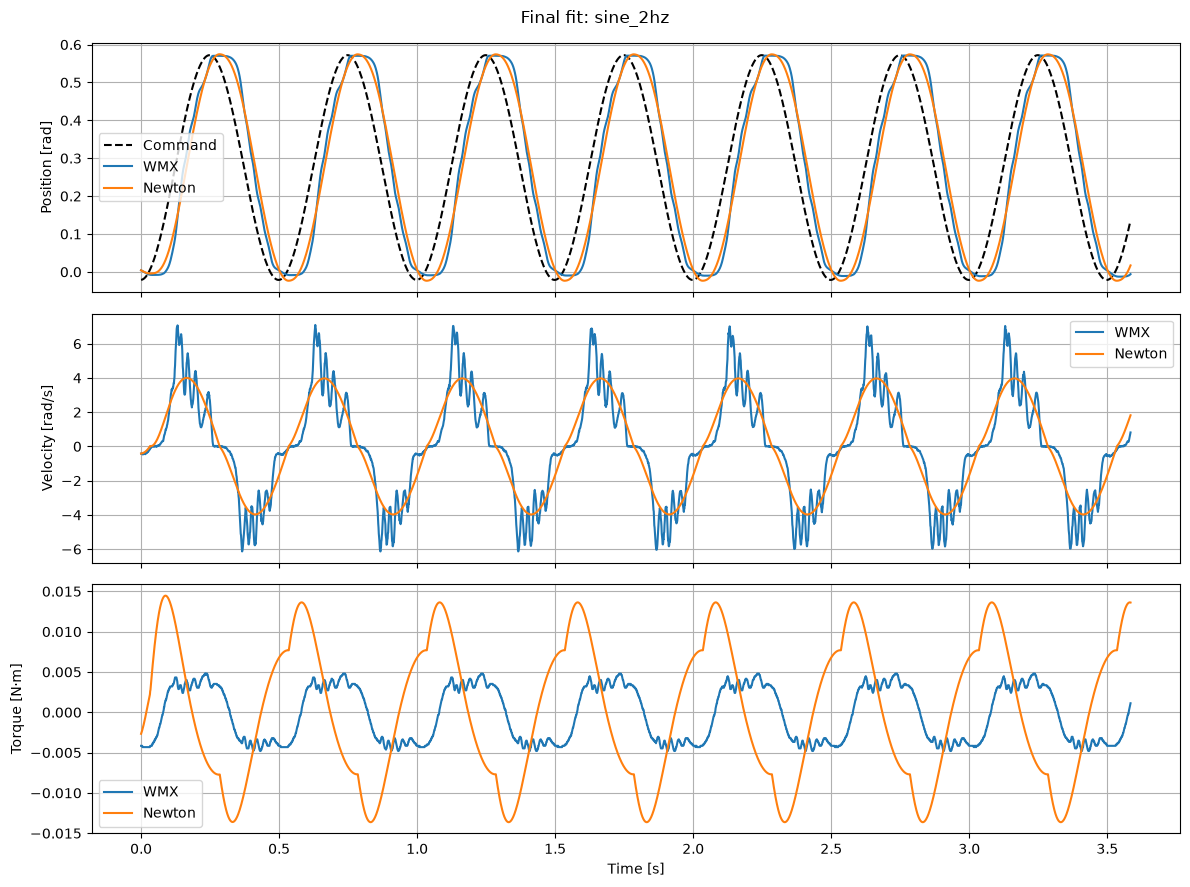

In [19]:
pre_refinement_params = current_params

refinement_views = [decimate_log(data, 1000) for data in fit_datasets]

REFINEMENT_WEIGHTS = {"position": 1.0, "velocity": 0.8, "torque": 0.8}
refinement_budget = 140
delay_polish_budget = 24

refinement_fit = fit_local_refinement(
    refinement_views, current_params, bounds_around(current_params),
    REFINEMENT_WEIGHTS, "전체 Newton 응답 미세조정",
    budget=refinement_budget, maxiter=35,
)
coarse_candidate = refinement_fit.params

delay_rechecked_params, _, delay_recheck = sweep_delay_steps(
    [step_window], coarse_candidate, delay_candidates, STEP_WEIGHTS,
    title="Step delay 재확인",
)
delay_before = int(coarse_candidate.delay_steps)
delay_after = int(delay_rechecked_params.delay_steps)
delay_changed = delay_after != delay_before
print(
    "delay 재확인:",
    {
        "before": delay_before,
        "after": delay_after,
        "step_loss": delay_recheck["losses"]["total"],
        "changed": delay_changed,
    },
)

if delay_changed:
    delay_polish_fit = fit_local_refinement(
        refinement_views, delay_rechecked_params, bounds_around(delay_rechecked_params),
        REFINEMENT_WEIGHTS, "Delay 갱신 후 짧은 미세조정",
        budget=delay_polish_budget, maxiter=10,
    )
    coarse_candidate = delay_polish_fit.params
else:
    coarse_candidate = delay_rechecked_params

baseline_full = evaluate_params(
    fit_datasets, pre_refinement_params, REFINEMENT_WEIGHTS,
    progress_title="원본 1 ms refinement 이전 응답",
)
candidate_full = evaluate_params(
    fit_datasets, coarse_candidate, REFINEMENT_WEIGHTS,
    progress_title="원본 1 ms refinement 후보 응답",
)
if candidate_full["losses"]["total"] < baseline_full["losses"]["total"]:
    current_params = coarse_candidate
    final_fit_evaluation = candidate_full
else:
    warnings.warn("원본 1 ms 응답이 악화되어 refinement 이전 값으로 되돌립니다.")
    current_params = pre_refinement_params
    final_fit_evaluation = baseline_full

print_evaluation("최종 fitting", current_params, final_fit_evaluation, fit_datasets)
for data, simulation in zip(fit_datasets, final_fit_evaluation["simulations"]):
    plot_comparison(data, simulation, f"Final fit: {data['profile']}")


## 8. 두 S-curve 검증



S-curve validation
params = {'kp': 0.23303367686865178, 'ki': 0.0, 'kd': 0.007724395727034785, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 0.0002240549907040991, 'viscous': 1.0000091888312144e-05, 'coulomb': 0.003432729715064069, 'delay_steps': 0, 'torque_response_time_constant': 0.0}
mean loss = {'position': 1.690069565947519, 'velocity': 1.629088631831337, 'torque': 7.865166961739544e-05, 'total': 1.1793694434992448}
  scurve_validation_1: {'position': 1.9764314640186216, 'velocity': 1.9062218065014744, 'torque': 7.716427679566031e-05, 'total': 1.3795169764847546}
  scurve_validation_2: {'position': 1.4037076678764164, 'velocity': 1.3519554571611996, 'torque': 8.013906243913058e-05, 'total': 0.9792219105137348}


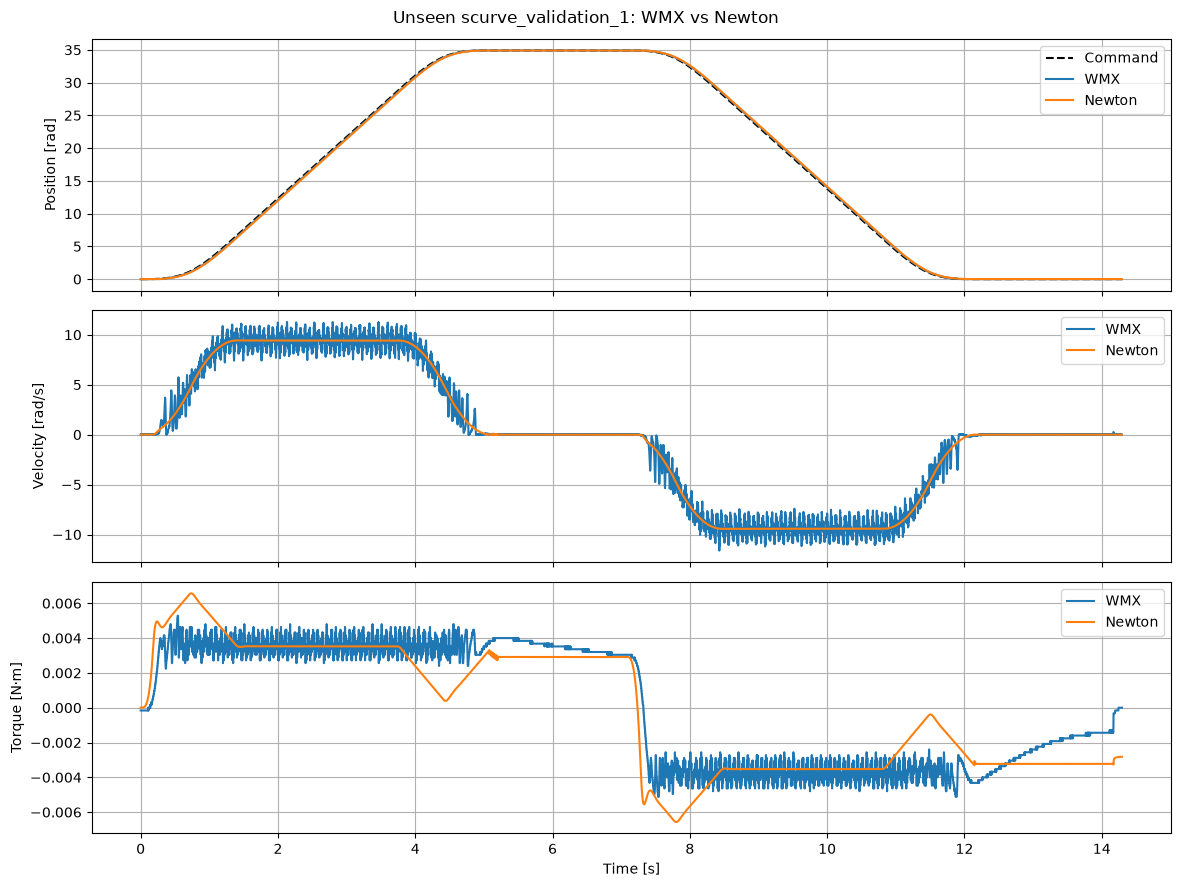

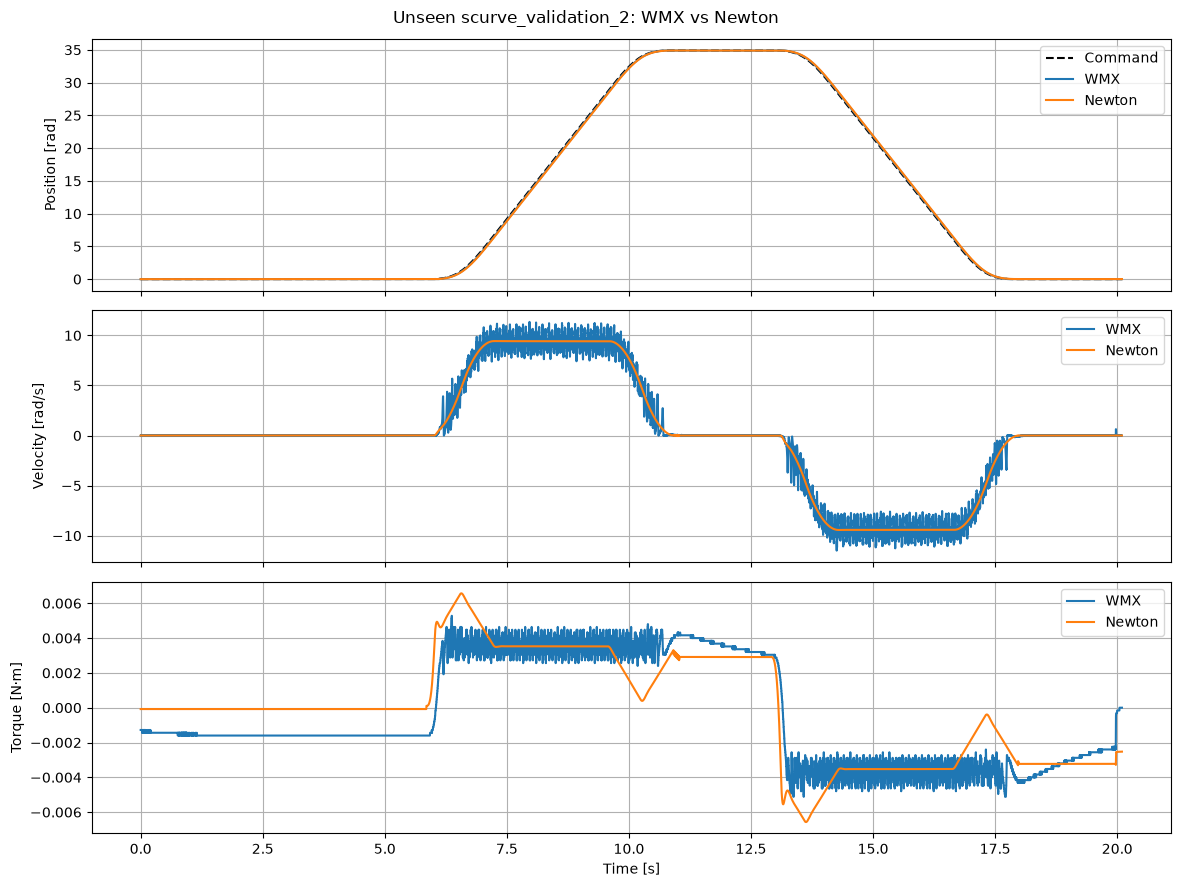

In [20]:

validation_evaluation = evaluate_params(
    validation_datasets, current_params, DEFAULT_WEIGHTS,
    progress_title="미사용 S-curve 2개 validation",
)
print_evaluation(
    "S-curve validation", current_params, validation_evaluation, validation_datasets,
)
for data, simulation in zip(validation_datasets, validation_evaluation["simulations"]):
    plot_comparison(
        data, simulation,
        f"Unseen {data['profile']}: WMX vs Newton",
    )


## 9. 결과 저장



In [21]:

RESULT_PATH = PROJECT_ROOT / "fitted_motor_params_init.json"
result_payload = {
    "motor_params": asdict(current_params),
    "fit_logs": {name: datasets[name]["source"] for name in fit_dataset_names},
    "validation_logs": {
        name: datasets[name]["source"] for name in validation_dataset_names
    },
    "fit_losses": final_fit_evaluation["losses"],
    "validation_losses": validation_evaluation["losses"],
}
RESULT_PATH.write_text(json.dumps(result_payload, indent=2), encoding="utf-8")
print("저장 완료:", RESULT_PATH.resolve())


저장 완료: /home/ireh21/rei/fitted_motor_params_init.json


## 10. 검증 및 확인


In [1]:
import sys
from pathlib import Path

project_root = globals().get("PROJECT_ROOT")
if project_root is None:
    project_root = next(
        (path for path in (Path.cwd(), *Path.cwd().parents)
         if (path / "code" / "single_motor_twin.py").exists()),
        None,
    )
if project_root is None:
    raise FileNotFoundError("code/single_motor_twin.py를 찾을 수 없습니다.")
if str(project_root / "code") not in sys.path:
    sys.path.insert(0, str(project_root / "code"))

from result_summary import print_summary, summarize_result_bundle

result_json = Path(globals().get("RESULT_PATH", project_root / "fitted_motor_params_init.json"))
summary = summarize_result_bundle(result_json, mode="04_3")
print_summary(summary)


Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, CUDA driver not available (NVRTC compilation available)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /home/ireh21/.cache/warp/1.16.0
Module validate_and_correct_inertia_kernel_5e18b3cd 2f0edb1 load on device 'cpu' took 1.97 ms  (cached)
Module newton._src.geometry.bvh 24ddd6d load on device 'cpu' took 0.36 ms  (cached)
Module newton._src.sim.articulation 57145c7 load on device 'cpu' took 0.49 ms  (cached)
Module newton._src.solvers.featherstone.kernels 4399e75 load on device 'cpu' took 0.63 ms  (cached)


Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


VALIDATION
  position_nrmse: 0.00460217
  velocity_nrmse: 0.105689
  torque_nrmse: 0.435214

STEP
  rise_error_s: 0.02
  settling_error_s: 0.126
  overshoot_error: 0.113921

RAMP
  torque_bias_abs: 0.000147293

SINE
  gain_abs_error: 0.0194863
  phase_abs_error_deg: 2.10774


35분 소요